**Adversarial B Fields - Free B version**

This approach uses a different philosophy from a traditional "fit topologically different M to a target B" optimization method. Since we just care about having an ambiguous B, there´s no need to fix a target B and unnecessarily restrict ourselves. Rather we perform multi variable optimization on 2 textures with a cost function that maintains topological charge difference, in addition to stray field mismatch and Tikhonov regularization (penalizes high spatial gradients).

**Setup and Textures**

In [1]:
#Global Font size for all plots
import matplotlib.pyplot as plt
#Set global font sizes
plt.rcParams.update({
    'font.size': 14,          # General text
    'axes.titlesize': 18,     # Subplot titles
    'axes.labelsize': 16,     # x and y labels
    'xtick.labelsize': 12,    # x-axis tick numbers
    'ytick.labelsize': 12,    # y-axis tick numbers
    'legend.fontsize': 14,    # Legend text
    'figure.titlesize': 20    # Overall figure title
})

Loss function, topological charge calculation

In [2]:
import torch
import numpy as np

class AmbiguousMagnetizationFree:
    """
    Find M1, M2 with different topologies but same B field.
    No target B specified!
    """

    def __init__(self, grid_shape, dx, dy, thickness, height, Ms): # Set Ms=1 here
        self.grid_shape = grid_shape
        self.dx = dx
        self.dy = dy
        self.thickness = thickness
        self.height = height
        self.Ms = Ms
        self.nx, self.ny = grid_shape
        self.N = self.nx * self.ny
        # Assuming MU_0 is a constant you need to define
        # For free space, MU_0 = 4 * pi * 1e-7 H/m
        self.MU_0 = 4 * np.pi * 1e-7


    def cost(self, M1_torch, M2_torch):
        """
        Free optimization: no target B!
        M1_torch, M2_torch: shape (3, N) - Torch tensors with requires_grad=True
        """
        # Inputs are expected to be Torch tensors

        # Reshape to grid: (3, N) -> (N, 3) -> (nx, ny, 3)
        # M1_grid = (M1_torch.T * self.Ms).reshape(self.nx, self.ny, 3) # Magnetization should be unit vectors here
        # M2_grid = (M2_torch.T * self.Ms).reshape(self.nx, self.ny, 3) # Magnetization should be unit vectors here
        M1_grid = M1_torch.T.reshape(self.nx, self.ny, 3)
        M2_grid = M2_torch.T.reshape(self.nx, self.ny, 3)


        # === Main objective: B fields should match ===
        B1 = self.compute_B_field(M1_grid) # Use optimized version
        B2 = self.compute_B_field(M2_grid) # Use optimized version
        cost_B = 3.5e17*torch.sum((B1 - B2)**2) #100


        # === Topology constraint: should differ by 1 ===
        # Use the PyTorch version for differentiability in the cost function
        Q1 = self.compute_skyrmion_number_torch(M1_grid)
        Q2 = self.compute_skyrmion_number_torch(M2_grid)
        cost_topology = 15000.333e-2 * (torch.abs(Q1 - Q2) - 0.5)**2 #15000.333e-2


        # === Smoothness constraint ===
        # Penalize sharp changes in M across the grid
        # Use the spatial_gradient method already defined
        grad_M1 = self.spatial_gradient(M1_grid)
        grad_M2 = self.spatial_gradient(M2_grid)
        cost_smoothness = 1e-18 * (torch.sum(grad_M1**2) + torch.sum(grad_M2**2)) # Sum of squared gradients. 1e-18


        # === Total cost ===
        #total = (cost_B + cost_topology + 0.1 * cost_structure + 0.1 * cost_difference + 0.1 * cost_magnitude)
        total = cost_B + cost_topology + cost_smoothness # Add the new smoothness cost
        # Return a Torch scalar
        return total


    def compute_B_field(self, M_grid, height=None):
        """
        Compute stray field B(x,y,h) above a thin magnetic film using a stable,
        dimensionally-correct Fourier-space scalar-potential kernel.

        Inputs
        -------
        M_grid : (Nx, Ny, 3) torch tensor (real)
            Magnetization in A/m: (Mx, My, Mz).
        height : float (meters) or None
            Standoff distance h. If None, uses self.height.

        Uses
        ----
        self.dx, self.dy : pixel sizes in meters
        self.thickness   : film thickness in meters
        self.MU_0        : vacuum permeability (T·m/A)

        Returns
        -------
        B : (Nx, Ny, 3) torch tensor (real)
            Stray field in Tesla: (Bx, By, Bz).
        """
        if height is None:
            height = self.height

        device = M_grid.device
        dtype = torch.float32
        M_grid = M_grid.to(device=device, dtype=dtype)

        nx, ny = M_grid.shape[0], M_grid.shape[1]

        # --------------------------
        # Symmetric zero-padding (center sample)
        # --------------------------
        nx_pad, ny_pad = 2 * nx, 2 * ny
        pad_x, pad_y = nx // 2, ny // 2

        M_padded = torch.zeros((nx_pad, ny_pad, 3), dtype=dtype, device=device)
        M_padded[pad_x:pad_x + nx, pad_y:pad_y + ny, :] = M_grid

        # --------------------------
        # FFT forward (real -> complex)
        # Use consistent normalization (forward/forward)
        # --------------------------
        M_fft = torch.fft.rfftn(M_padded, s=(nx_pad, ny_pad), dim=(0, 1), norm='forward')
        cplx_dtype = M_fft.dtype

        # --------------------------
        # k-vectors for padded domain (rad/m)
        # --------------------------
        kx = (2.0 * torch.pi * torch.fft.fftfreq(nx_pad, d=float(self.dx))).to(device=device, dtype=dtype)
        ky = (2.0 * torch.pi * torch.fft.rfftfreq(ny_pad, d=float(self.dy))).to(device=device, dtype=dtype)
        kx_grid, ky_grid = torch.meshgrid(kx, ky, indexing="ij")  # (nx_pad, ny_pad//2+1)

        k_mag = torch.sqrt(kx_grid**2 + ky_grid**2)

        # masks + safe k for division
        k_zero_mask = (k_mag == 0.0)
        eps = 1e-30  # small number; units (rad/m)^2 inside sqrt
        k_safe = torch.sqrt(k_mag**2 + eps)

        # --------------------------
        # Thin-film factors
        # --------------------------
        # attenuation exp(-k h)
        attenuation = torch.exp(-k_safe * float(height))

        # thickness factor: (1 - exp(-k t)) computed stably
        kt = k_safe * float(self.thickness)
        thickness_factor = -torch.expm1(-kt)  # 1 - exp(-k t)

        # prefactor F(k) = (mu0/2) * (1 - exp(-k t)) * exp(-k h)
        F_real = 0.5 * float(self.MU_0) * thickness_factor * attenuation

        # Promote to complex for multiplication with FFT quantities
        kx_c = kx_grid.to(dtype=cplx_dtype)
        ky_c = ky_grid.to(dtype=cplx_dtype)
        k_c  = k_safe.to(dtype=cplx_dtype)
        F    = F_real.to(dtype=cplx_dtype)

        # --------------------------
        # Sources in k-space
        # --------------------------
        # k · M_parallel = kx*Mx + ky*My
        k_dot_Mpar = kx_c * M_fft[..., 0] + ky_c * M_fft[..., 1]
        Mz = M_fft[..., 2]

        # Inverses (avoid divide-by-zero)
        inv_k  = torch.zeros_like(k_safe, dtype=cplx_dtype, device=device)
        inv_k2 = torch.zeros_like(k_safe, dtype=cplx_dtype, device=device)
        nonzero = ~k_zero_mask
        inv_k[nonzero]  = (1.0 / k_safe[nonzero]).to(cplx_dtype)
        inv_k2[nonzero] = (1.0 / (k_safe[nonzero]**2)).to(cplx_dtype)

        # --------------------------
        # Scalar potential kernel (dimensionally correct)
        # phi(k,h) = F(k) * [ Mz/k + i (k·Mpar)/k^2 ]
        # Then Bx = -i kx phi, By = -i ky phi, Bz = +k phi (for z>0)
        # --------------------------
        phi = F * (Mz * inv_k + 1j * k_dot_Mpar * inv_k2)

        B_fft = torch.zeros_like(M_fft, dtype=cplx_dtype)
        B_fft[..., 0] = -1j * kx_c * phi
        B_fft[..., 1] = -1j * ky_c * phi
        B_fft[..., 2] =  -k_c * phi

        # No DC stray field in this formulation
        if k_zero_mask.any():
            B_fft = B_fft.clone()
            B_fft[k_zero_mask, :] = 0.0 + 0.0j

        # --------------------------
        # Inverse FFT -> real-space (padded)
        # --------------------------
        B_padded = torch.fft.irfftn(B_fft, s=(nx_pad, ny_pad), dim=(0, 1), norm='forward')

        # --------------------------
        # Crop back to original grid
        # --------------------------
        B = B_padded[pad_x:pad_x + nx, pad_y:pad_y + ny, :]

        return B


    def compute_skyrmion_number_torch(self, m):
        """
        Differentiable topological charge using Torch operations for optimization,
        mimicking the NumPy slicing approach for finite differences.
        Q = (1/4π) ∫∫ m·(∂x m × ∂y m) dA
        """
        # Ensure input is Torch tensor
        if not isinstance(m, torch.Tensor):
             raise TypeError("Input magnetization 'm' must be a Torch tensor.")

        if m.ndim != 3 or m.shape[2] != 3:
            raise ValueError("Input magnetization 'm' must have shape (Ny, Nx, 3).")

        # Normalize the magnetization vectors (if not already unit vectors)
        m_norm = m / (torch.linalg.norm(m, dim=2, keepdim=True) + 1e-9)

        # 1. Get magnetization vectors at adjacent points using slicing
        # m_r corresponds to m_norm[y, x]
        m_r = m_norm[:-1, :-1]

        # m_{r+x} corresponds to m_norm[y, x+1] (shifted by 1 in the x-direction)
        m_r_plus_x = m_norm[:-1, 1:]

        # m_{r+y} corresponds to m_norm[y+1, x] (shifted by 1 in the y-direction)
        m_r_plus_y = m_norm[1:, :-1]

        # 2. Compute the cross product term: (m_{r+x} x m_{r+y}) using torch.linalg.cross
        # torch.linalg.cross performs the cross product along the last axis (axis=-1)
        cross_product = torch.linalg.cross(m_r_plus_x, m_r_plus_y, dim=-1)

        # 3. Compute the scalar triple product (dot product): m_r . cross_product using torch.sum
        # torch.sum along the last axis (axis=-1) performs the dot product for each (x,y) cell
        scalar_triple_product = torch.sum(m_r * cross_product, dim=-1)

        Q = torch.sum(scalar_triple_product) / (4 * torch.pi)

        return Q


    def spatial_gradient(self, M_grid):
        """
        Compute spatial gradients for structure measure.
        Returns: gradient tensor
        """
        grad_x = torch.gradient(M_grid, spacing=(self.dx,), dim=0)[0]
        grad_y = torch.gradient(M_grid, spacing=(self.dy,), dim=1)[0]
        return torch.stack([grad_x, grad_y], dim=-1)

Standard textures: skyrmion, meron, fractional, uniform

In [3]:
## @title
import torch
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

def generate_skyrmion(nx, ny, Ms=1, sign=1, device='cpu'):
    """Generate a simple Bloch skyrmion pattern."""
    #By changing sign from 1 to -1 you can flip the polarity of the skyrmion
    x = torch.linspace(-1, 1, nx, device=device)
    y = torch.linspace(-1, 1, ny, device=device)
    xx, yy = torch.meshgrid(x, y, indexing='ij')

    r = torch.sqrt(xx**2 + yy**2)
    phi = torch.atan2(yy, xx)

    # Skyrmion profile
    R_sky = 0.3
    theta = torch.pi * (1 - torch.tanh(r / R_sky))
    #theta = 2 * torch.arctan(r / R_sky)

    M = torch.zeros((nx, ny, 3), device=device)
    M[..., 0] = torch.sin(theta) * torch.cos(phi + torch.pi/2)  # mx
    M[..., 1] = torch.sin(theta) * torch.sin(phi + torch.pi/2)  # my
    M[..., 2] = -sign*torch.cos(theta)                                # mz

    return M * Ms

def generate_vortex(nx, ny, Ms=1, sign=1, device='cpu'):
    """Generate a simple vortex (meron) pattern."""
    #By changing sign from 1 to -1 you can flip the polarity of the meron
    x = torch.linspace(-1, 1, nx, device=device)
    y = torch.linspace(-1, 1, ny, device=device)
    xx, yy = torch.meshgrid(x, y, indexing='ij')

    r = torch.sqrt(xx**2 + yy**2)
    phi = torch.atan2(yy, xx)

    # Meron profile
    R_core = 0.2
    theta = (torch.pi / 2) * (1 - torch.exp(-(r / R_core)**2))

    M = torch.zeros((nx, ny, 3), device=device)
    M[..., 0] = -torch.sin(phi) * torch.sin(theta)  # mx
    M[..., 1] = torch.cos(phi) * torch.sin(theta)   # my
    M[..., 2] = sign*torch.cos(theta)                    # mz

    return M * Ms

#Fractional

def generate_fractional_Q(nx, ny, Q_target=0.25, Ms=1, sign=1, R_core=0.15, device='cpu'):
    """
    Generate a fractional vortex texture with specified topological charge Q.

    Based on del Ser et al., Phys. Rev. B 110, 094442 (2024), Section II.

    Physics: In an easy-plane ferromagnet with out-of-plane magnetic field,
    the ground state is tilted at angle θ_FM from z-axis. A vortex covers
    only a fraction of the unit sphere:

        Q = ±(1/2)(1 - cos(θ_FM))

    The key insight: fractional Q comes from PARTIAL SPHERE COVERAGE,
    NOT fractional winding number. The azimuthal winding remains integer.

    Args:
        nx, ny: grid dimensions
        Q_target: target topological charge magnitude (0 < |Q| ≤ 0.5)
                  Q = 0.25 → θ_FM = 60° (texture covers 1/4 of sphere)
                  Q = 0.50 → θ_FM = 90° (standard meron, 1/2 sphere)
        Ms: saturation magnetization
        sign: +1 for core up (positive Q), -1 for core down (negative Q)
        R_core: vortex core radius in normalized units
        device: torch device

    Returns:
        M: [nx, ny, 3] magnetization tensor
    """
    if not (0 < abs(Q_target) <= 0.5):
        raise ValueError(f"Q_target must satisfy 0 < |Q| ≤ 0.5, got {Q_target}")

    x = torch.linspace(-1, 1, nx, device=device)
    y = torch.linspace(-1, 1, ny, device=device)
    xx, yy = torch.meshgrid(x, y, indexing='ij')

    r = torch.sqrt(xx**2 + yy**2)
    phi = torch.atan2(yy, xx)

    # From Q = (1/2)(1 - cos(θ_FM)), solve for θ_FM
    Q_mag = abs(Q_target)
    cos_theta_FM = 1.0 - 2.0 * Q_mag
    theta_FM = float(torch.acos(torch.tensor(cos_theta_FM, device=device)))

    # Smooth vortex profile: θ goes from 0 at core to θ_FM at infinity
    theta = theta_FM * (1 - torch.exp(-(r / R_core)**2))

    # INTEGER azimuthal winding (winding number = 1)
    # In-plane magnetization circulates: m_⊥ ∝ (-sin(φ), cos(φ))
    M = torch.zeros((nx, ny, 3), device=device)
    M[..., 0] = -torch.sin(phi) * torch.sin(theta)
    M[..., 1] = torch.cos(phi) * torch.sin(theta)
    M[..., 2] = sign * torch.cos(theta)

    return M * Ms

def generate_uniform_inplane(nx, ny, Ms=1, angle_deg=0, device='cpu'):
    """
    Generate uniform in-plane magnetization.

    Args:
        nx, ny: grid dimensions
        Ms: saturation magnetization (A/m)
        angle_deg: in-plane angle in degrees (0° = +x, 90° = +y)
        device: torch device

    Returns:
        M: [nx, ny, 3] magnetization tensor in A/m
    """
    # Convert angle to radians
    angle_rad = torch.tensor(angle_deg * torch.pi / 180, device=device)

    M = torch.zeros((nx, ny, 3), device=device)
    M[..., 0] = torch.cos(angle_rad)  # Mx
    M[..., 1] = torch.sin(angle_rad)  # My
    M[..., 2] = 0.0                   # Mz = 0 (in-plane)

    return M * Ms

def plot_3d_magnetization_fixed(M, title, downsample=4):
    """Plot normalized magnetization vectors in 3D space."""
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    M_np = M.detach().cpu().numpy()

    # Downsample for clarity
    nx, ny, _ = M_np.shape
    x = np.arange(nx)
    y = np.arange(ny)
    X, Y = np.meshgrid(x, y, indexing='ij')
    Z = np.zeros_like(X)  # All in z=0 plane

    # Downsample
    X_ds = X[::downsample, ::downsample]
    Y_ds = Y[::downsample, ::downsample]
    Z_ds = Z[::downsample, ::downsample]
    Mx_ds = M_np[::downsample, ::downsample, 0]
    My_ds = M_np[::downsample, ::downsample, 1]
    Mz_ds = M_np[::downsample, ::downsample, 2]

    # NORMALIZE the vectors for visualization
    # Calculate magnitudes and normalize
    magnitudes = np.sqrt(Mx_ds**2 + My_ds**2 + Mz_ds**2)
    Mx_norm = Mx_ds / (magnitudes + 1e-12)  # Add small epsilon to avoid division by zero
    My_norm = My_ds / (magnitudes + 1e-12)
    Mz_norm = Mz_ds / (magnitudes + 1e-12)

    # Plot normalized vectors with fixed length
    ax.quiver(X_ds, Y_ds, Z_ds, Mx_norm, My_norm, Mz_norm,
              length=0.6, normalize=False, color='red', alpha=0.7,
              linewidth=1.5, arrow_length_ratio=0.3)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'{title} - Normalized Vectors')
    ax.set_xlim(0, nx)
    ax.set_ylim(0, ny)
    ax.set_zlim(-1, 1)  # Constrain z-axis since all vectors are in plane
    ax.set_box_aspect([1, 1, 0.3])

    return fig


"""
# Main execution
if __name__ == "__main__":
    device = 'cpu'

    # Generate patterns
    nx, ny = 32, 32
    skyrmion = generate_skyrmion(nx, ny, device=device)
    vortex = generate_vortex(nx, ny, device=device)
    uniform = generate_uniform_inplane(nx=nx, ny=ny, device=device)
    fractional = generate_fractional_Q(nx, ny, device=device)

    print("Original magnetization magnitudes:")
    print(f"Skyrmion: {torch.norm(skyrmion, dim=2).max():.2e} A/m")
    print(f"Vortex: {torch.norm(vortex, dim=2).max():.2e} A/m")
    print(f"Uniform: {torch.norm(uniform, dim=2).max():.2e} A/m")
    print(f"Fractional: {torch.norm(fractional, dim=2).max():.2e} A/m")
    print("\nNow plotting NORMALIZED vectors for visualization...")

    # Fixed 3D plots with normalized vectors
    plot_3d_magnetization_fixed(skyrmion, "Skyrmion")
    plot_3d_magnetization_fixed(vortex, "Vortex")
    plot_3d_magnetization_fixed(uniform, "Uniform")
    plot_3d_magnetization_fixed(fractional, "Fractional")

    plt.show()
"""

'\n# Main execution\nif __name__ == "__main__":\n    device = \'cpu\'\n\n    # Generate patterns\n    nx, ny = 32, 32\n    skyrmion = generate_skyrmion(nx, ny, device=device)\n    vortex = generate_vortex(nx, ny, device=device)\n    uniform = generate_uniform_inplane(nx=nx, ny=ny, device=device)\n    fractional = generate_fractional_Q(nx, ny, device=device)\n\n    print("Original magnetization magnitudes:")\n    print(f"Skyrmion: {torch.norm(skyrmion, dim=2).max():.2e} A/m")\n    print(f"Vortex: {torch.norm(vortex, dim=2).max():.2e} A/m")\n    print(f"Uniform: {torch.norm(uniform, dim=2).max():.2e} A/m")\n    print(f"Fractional: {torch.norm(fractional, dim=2).max():.2e} A/m")\n    print("\nNow plotting NORMALIZED vectors for visualization...")\n\n    # Fixed 3D plots with normalized vectors\n    plot_3d_magnetization_fixed(skyrmion, "Skyrmion")\n    plot_3d_magnetization_fixed(vortex, "Vortex")\n    plot_3d_magnetization_fixed(uniform, "Uniform")\n    plot_3d_magnetization_fixed(fracti

Using device: cpu


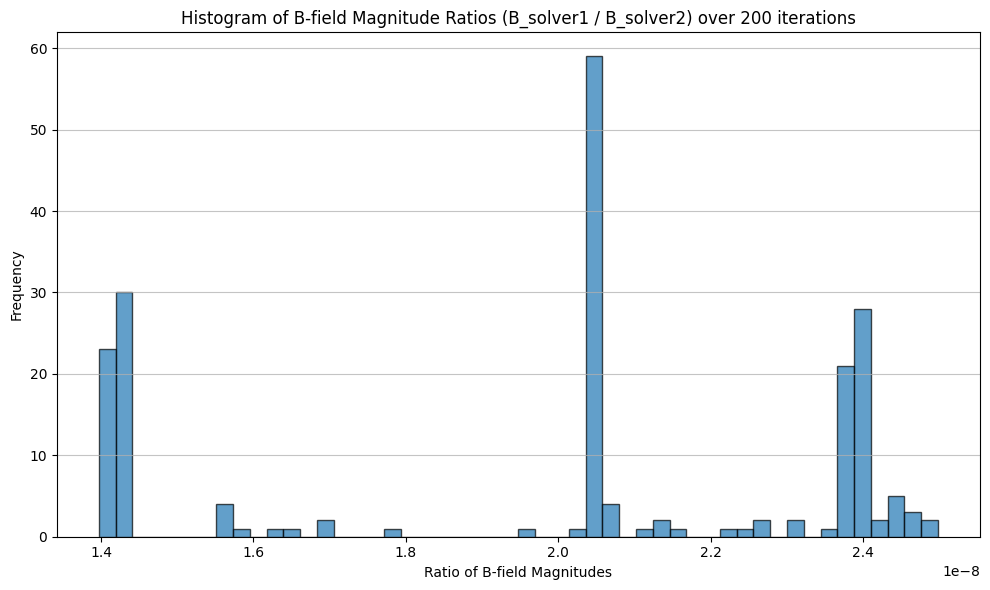

Average ratio: 0.0000
Standard deviation of ratio: 0.0000


In [ ]:
# @title
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

# --- Configuration Parameters ---
nx, ny = 32, 32 # From kernel state
Ms_val = 1e6 # A/m (saturation magnetization)
dx = 5e-9 # meters (spatial resolution)
dy = 5e-9 # meters (spatial resolution)
thickness = 1e-9 # meters (film thickness)
fixed_height_B = 20e-9 # meters (20 nm standoff height for B-field calculation)
perturbation_strength = 0.05 # Fraction of unit vector magnitude for perturbation
num_iterations = 200 # Number of random magnetizations to generate and test
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {device}")

# --- Instantiate the AmbiguousMagnetizationFree solver ---
solver = AmbiguousMagnetizationFree(grid_shape=(nx, ny), dx=dx, dy=dy, thickness=thickness, height=fixed_height_B, Ms=Ms_val)

# List of magnetization generation functions
generator_functions = [
    generate_skyrmion,
    generate_vortex,
    generate_fractional_Q,
    generate_uniform_inplane
]

# Store ratios
b_field_ratios = []

for i in range(num_iterations):
    # 1. Choose a random magnetization pattern generator
    gen_func = random.choice(generator_functions)

    # 2. Generate a base magnetization (Ms=1 for unit vectors)
    if gen_func == generate_fractional_Q:
        # fractional_Q requires Q_target, let's randomize it within a reasonable range
        Q_target = random.uniform(0.1, 0.45)
        sign = random.choice([-1, 1])
        M_base_unit = gen_func(nx, ny, Ms=1, sign=sign, Q_target=Q_target, device=device)
    elif gen_func == generate_uniform_inplane:
        angle_deg = random.uniform(0, 360)
        M_base_unit = gen_func(nx, ny, Ms=1, angle_deg=angle_deg, device=device)
    else:
        # Skyrmion and Vortex can have their sign randomized
        sign = random.choice([-1, 1])
        M_base_unit = gen_func(nx, ny, Ms=1, sign=sign, device=device)

    # 3. Add a small random perturbation
    # Generate random perturbation with values between -perturbation_strength and +perturbation_strength
    perturbation = (torch.rand((nx, ny, 3), device=device) * 2 - 1) * perturbation_strength

    # Add perturbation to the unit vectors
    M_perturbed_unit = M_base_unit + perturbation

    # 4. Re-normalize to unit vectors and scale by Ms_val to get A/m values
    # Add a small epsilon to avoid division by zero for very small magnitudes
    M_grid_input = M_perturbed_unit / (torch.linalg.norm(M_perturbed_unit, dim=2, keepdim=True) + 1e-9) * Ms_val

    # 5. Calculate stray fields using both methods
    B1 = solver.compute_B_field(M_grid_input, height=fixed_height_B)
    B2 = solver.compute_B_field_t(M_grid_input, height=fixed_height_B)

    # 6. Calculate magnitude of B fields and their ratio
    norm_B1 = torch.norm(B1)
    norm_B2 = torch.norm(B2)

    # Store the ratio, avoiding division by zero for very small fields
    if norm_B2 > 1e-15:
        ratio = norm_B1 / norm_B2
        b_field_ratios.append(ratio.item()) # .item() to get Python scalar from Torch tensor

# --- Plotting the histogram of ratios ---
plt.figure(figsize=(10, 6))
plt.hist(b_field_ratios, bins=50, edgecolor='black', alpha=0.7)
plt.title(f'Histogram of B-field Magnitude Ratios (B_solver1 / B_solver2) over {num_iterations} iterations')
plt.xlabel('Ratio of B-field Magnitudes')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

print(f"Average ratio: {np.mean(b_field_ratios):.4f}")
print(f"Standard deviation of ratio: {np.std(b_field_ratios):.4f}")

## **Optimization**

Demo case for skyrmion and meron textures

/tmp/ipykernel_695/627019409.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  M1_init_torch = torch.tensor(M1_init_np, dtype=torch.float64, requires_grad=True)
/tmp/ipykernel_695/627019409.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  M2_init_torch = torch.tensor(M2_init_np, dtype=torch.float64, requires_grad=True)
/tmp/ipykernel_695/627019409.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  M1_init_grid_torch = torch.tensor(M1_init_grid, dtype=torch.float64, requires_grad=True)
/tmp/ipykernel_695/627019409.py:37: UserWarni

Skyrmion charge for initial M1: -0.90
Skyrmion charge for initial M2: -0.48


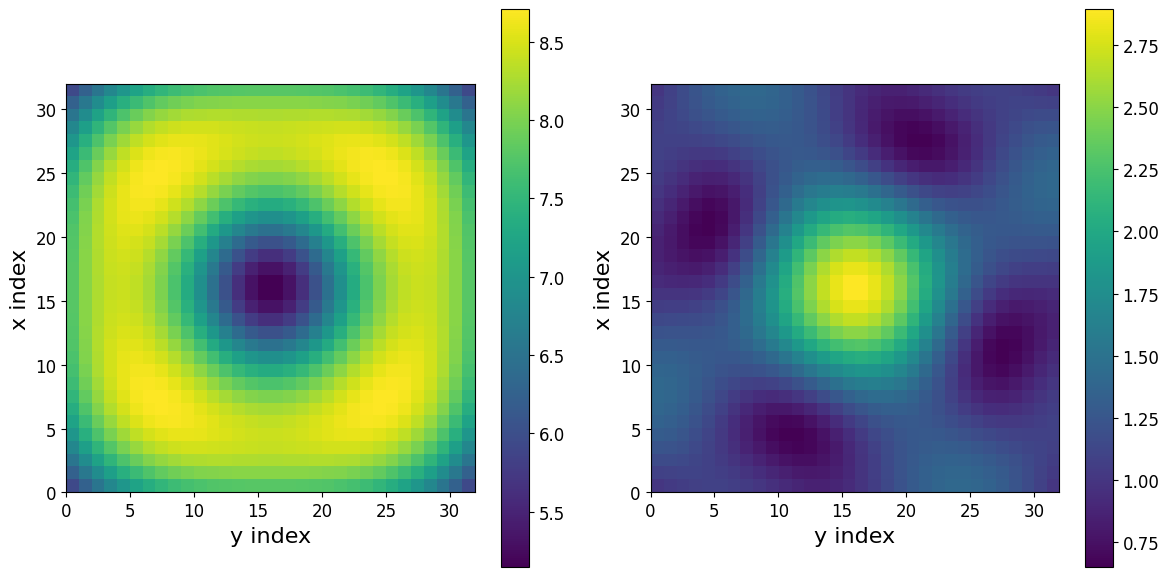

Root Mean Square Error (RMSE) between B1_init and B2_init: 4.98e-09 T
Average B field magnitude for normalization: 4.57e-09 T
Normalized Root Mean Square Error (NRMSE) for initial fields: 1.0899
Average magnitude of initial M1: 1.00e+00
Average magnitude of initial M2: 1.00e+00
Initial Cost: 26693.26240384591


In [4]:
# Initialize starting Magnetizations and plot their stray field maps
import matplotlib.pyplot as plt
import numpy as np
import torch
from mpl_toolkits.mplot3d import Axes3D

# Create problem instance (assuming AmbiguousMagnetizationFree class is defined)
problem = AmbiguousMagnetizationFree(
    grid_shape=(32, 32),
    dx=2e-9, dy=2e-9,
    thickness=1e-9, height=20e-9, # Set height to 20e-9
    Ms=1 # Set Ms=1 here, keep Ms=1 for better numerical stability during the actual calculations and optimization. Only multiply back by 1e6 at the very end, just before plotting.
    #We can do this because the stray field is linear wrt M
)

# Create initial magnetization states (assuming generate_skyrmion and generate_vortex are defined)
# These should now generate unit vectors since Ms=1
M1_init_np = generate_skyrmion(32, 32, Ms=problem.Ms)
M2_init_np = generate_vortex(32, 32, Ms=problem.Ms)


# Convert NumPy arrays to Torch tensors for calculations
# Ensure these tensors have requires_grad=True for optimization later
M1_init_torch = torch.tensor(M1_init_np, dtype=torch.float64, requires_grad=True)
M2_init_torch = torch.tensor(M2_init_np, dtype=torch.float64, requires_grad=True)


# Reshape to grid for plotting and B field calculation (nx, ny, 3)
# These are now unit vectors since Ms=1
M1_init_grid = M1_init_np.reshape(problem.nx, problem.ny, 3)
M2_init_grid = M2_init_np.reshape(problem.nx, problem.ny, 3)


# Convert grid arrays to Torch tensors for B field calculations
# These are now unit vectors
M1_init_grid_torch = torch.tensor(M1_init_grid, dtype=torch.float64, requires_grad=True)
M2_init_grid_torch = torch.tensor(M2_init_grid, dtype=torch.float64, requires_grad=True)



# Compute B fields for initial configurations
# Pass the unit vector grid tensors to compute_B_field
B1_init = problem.compute_B_field(M1_init_grid_torch)
B2_init = problem.compute_B_field(M2_init_grid_torch)


# Convert B fields to NumPy for plotting
B1_init_np = B1_init.detach().cpu().numpy()
B2_init_np = B2_init.detach().cpu().numpy()


# Calculate B field magnitudes for plotting
B1_init_mag_np = np.linalg.norm(B1_init_np, axis=-1)
B2_init_mag_np = np.linalg.norm(B2_init_np, axis=-1)


# Compute and print initial skyrmion numbers
# The compute_skyrmion_number_torch method handles normalization internally
Q1_init = problem.compute_skyrmion_number_torch(M1_init_grid_torch)
Q2_init = problem.compute_skyrmion_number_torch(M2_init_grid_torch)


print(f"Skyrmion charge for initial M1: {Q1_init:.2f}")
print(f"Skyrmion charge for initial M2: {Q2_init:.2f}")



# === Plotting ===
nx, ny = problem.grid_shape
X, Y = np.meshgrid(np.arange(nx), np.arange(ny), indexing='ij')



# 2D Plotting of Initial B Field Magnitude
fig_b, axes_b = plt.subplots(1, 2, figsize=(12, 6))

# |B| from M1
im1 = axes_b[0].imshow(B1_init_mag_np*1e9, origin='lower', cmap='viridis', extent=[0, ny, 0, nx]) #Rescaling back to realistic magnetization, 1e9 because 1e6 for the Magnetization and 1e3 for mili Tesla
#axes_b[0].set_title('|B| from Initial M1 in mT')
axes_b[0].set_xlabel('y index')
axes_b[0].set_ylabel('x index')
fig_b.colorbar(im1, ax=axes_b[0])

# |B| from M2

im2 = axes_b[1].imshow(B2_init_mag_np*1e9, origin='lower', cmap='viridis', extent=[0, ny, 0, nx]) #Rescaling back to realistic magnetization, 1e9 because 1e6 for the Magnetization and 1e3 for mili Tesla
#axes_b[1].set_title('|B| from Initial M2 in mT')
axes_b[1].set_xlabel('y index')
axes_b[1].set_ylabel('x index')
fig_b.colorbar(im2, ax=axes_b[1])

plt.tight_layout()
plt.show()

# Calculate the difference between the initial B fields
B_diff_init = B1_init - B2_init

# Calculate the squared difference
B_diff_squared_init = B_diff_init**2

# Calculate the mean squared error (MSE) over all components and grid points
mse_init = torch.mean(B_diff_squared_init)

# Calculate the Root Mean Squared Error (RMSE)
rmse_init = torch.sqrt(mse_init)

# Calculate the average magnitude of the initial B fields for normalization
average_B_magnitude_init = torch.mean(torch.linalg.norm(B1_init, dim=-1) + torch.linalg.norm(B2_init, dim=-1))/ 2.0

# Avoid division by zero if average magnitude is very small
epsilon = 1e-12
normalization_factor_init = torch.maximum(average_B_magnitude_init, torch.tensor(epsilon))

# Calculate the Normalized Root Mean Square Error (NRMSE)
nrmse_init = rmse_init / normalization_factor_init

print(f"Root Mean Square Error (RMSE) between B1_init and B2_init: {rmse_init.item():.2e} T")
print(f"Average B field magnitude for normalization: {normalization_factor_init.item():.2e} T")
print(f"Normalized Root Mean Square Error (NRMSE) for initial fields: {nrmse_init.item():.4f}")


# Calculate the average magnitude of the initial magnetizations
M1_init_magnitudes = torch.linalg.norm(M1_init_grid_torch, dim=2)
M2_init_magnitudes = torch.linalg.norm(M2_init_grid_torch, dim=2)

average_M1_init_magnitude = torch.mean(M1_init_magnitudes)
average_M2_init_magnitude = torch.mean(M2_init_magnitudes)

print(f"Average magnitude of initial M1: {average_M1_init_magnitude.item():.2e}")
print(f"Average magnitude of initial M2: {average_M2_init_magnitude.item():.2e}")



# Now call the cost method on the problem instance with Torch tensors
# The cost function expects M1 and M2 to be (3, N) tensors *after* scaling by Ms
# Reshape M1_init_torch and M2_init_torch from (nx, ny, 3) to (3, nx*ny)
M1_init_torch_flat = M1_init_torch.reshape(-1, 3).T
M2_init_torch_flat = M2_init_torch.reshape(-1, 3).T


val = problem.cost(M1_init_torch_flat, M2_init_torch_flat)
print("Initial Cost:", val.item())
#val

Component wise stray field plotting of the initial textures

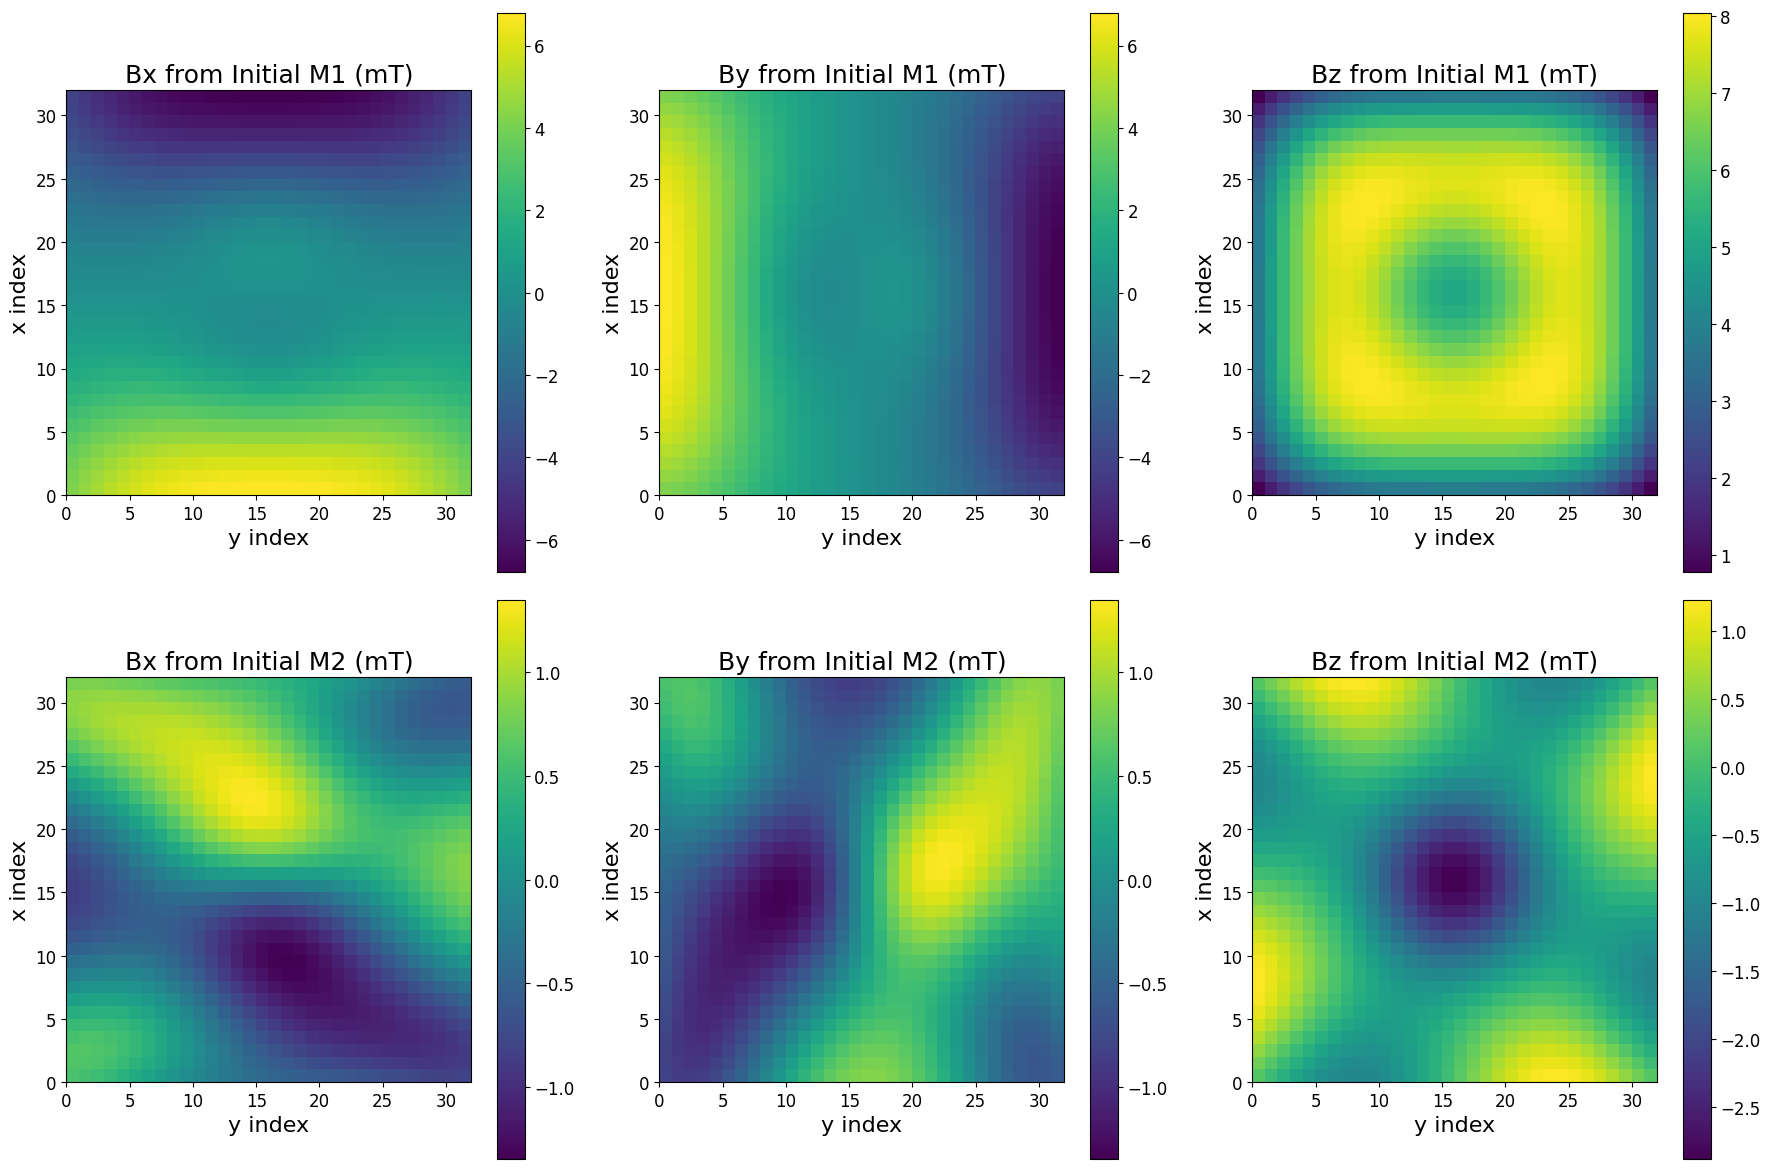

Individual B-field components (Bx, By, Bz) plotted for both optimized magnetizations.


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Assuming B1_init and B2_init are available from previous cells
# These are Torch tensors in the grid shape (nx, ny, 3)

# Convert Torch tensors to NumPy for plotting
B1_init_np = B1_init.detach().cpu().numpy()
B2_init_np = B2_init.detach().cpu().numpy()

nx, ny = problem.grid_shape

fig, axes = plt.subplots(2, 3, figsize=(18, 12)) # 2 rows (for M1, M2), 3 columns (for Bx, By, Bz)

# Plot Bx, By, Bz for M1
im1_bx = axes[0, 0].imshow(B1_init_np[:, :, 0]*1e9, origin='lower', cmap='viridis', extent=[0, ny, 0, nx])
axes[0, 0].set_title('Bx from Initial M1 (mT)')
axes[0, 0].set_xlabel('y index')
axes[0, 0].set_ylabel('x index')
fig.colorbar(im1_bx, ax=axes[0, 0])

im1_by = axes[0, 1].imshow(B1_init_np[:, :, 1]*1e9, origin='lower', cmap='viridis', extent=[0, ny, 0, nx])
axes[0, 1].set_title('By from Initial M1 (mT)')
axes[0, 1].set_xlabel('y index')
axes[0, 1].set_ylabel('x index')
fig.colorbar(im1_by, ax=axes[0, 1])

im1_bz = axes[0, 2].imshow(B1_init_np[:, :, 2]*1e9, origin='lower', cmap='viridis', extent=[0, ny, 0, nx])
axes[0, 2].set_title('Bz from Initial M1 (mT)')
axes[0, 2].set_xlabel('y index')
axes[0, 2].set_ylabel('x index')
fig.colorbar(im1_bz, ax=axes[0, 2])

# Plot Bx, By, Bz for M2
im2_bx = axes[1, 0].imshow(B2_init_np[:, :, 0]*1e9, origin='lower', cmap='viridis', extent=[0, ny, 0, nx])
axes[1, 0].set_title('Bx from Initial M2 (mT)')
axes[1, 0].set_xlabel('y index')
axes[1, 0].set_ylabel('x index')
fig.colorbar(im2_bx, ax=axes[1, 0])

im2_by = axes[1, 1].imshow(B2_init_np[:, :, 1]*1e9, origin='lower', cmap='viridis', extent=[0, ny, 0, nx])
axes[1, 1].set_title('By from Initial M2 (mT)')
axes[1, 1].set_xlabel('y index')
axes[1, 1].set_ylabel('x index')
fig.colorbar(im2_by, ax=axes[1, 1])

im2_bz = axes[1, 2].imshow(B2_init_np[:, :, 2]*1e9, origin='lower', cmap='viridis', extent=[0, ny, 0, nx])
axes[1, 2].set_title('Bz from Initial M2 (mT)')
axes[1, 2].set_xlabel('y index')
axes[1, 2].set_ylabel('x index')
fig.colorbar(im2_bz, ax=axes[1, 2])

plt.tight_layout()
plt.show()

print("Individual B-field components (Bx, By, Bz) plotted for both optimized magnetizations.")

In [ ]:
# @title
#Field mismatch
print(3.5e17*torch.sum((B1_init - B2_init)**2))
#Topology
Q1 = problem.compute_skyrmion_number_torch(M1_init_torch)
Q2 = problem.compute_skyrmion_number_torch(M2_init_torch)
cost_topology = 15000.33333e-2 * (torch.abs(Q1 - Q2) - 0.5)**2
print(cost_topology)
#Tikhonov
grad_M1 = problem.spatial_gradient(M1_init_torch)
grad_M2 = problem.spatial_gradient(M2_init_torch)
cost_smoothness = 1e-18 * (torch.sum(grad_M1**2) + torch.sum(grad_M2**2))
print(cost_smoothness)


tensor(26681.2109, grad_fn=<MulBackward0>)
tensor(0.9746, dtype=torch.float64, grad_fn=<MulBackward0>)
tensor(11.0768, dtype=torch.float64, grad_fn=<MulBackward0>)


**Run the Optimization**

Starting PyTorch optimization loop...
Iteration 2/450, Cost: 2.4101e+04
Iteration 50/450, Cost: 2.3582e+02
Iteration 100/450, Cost: 8.8353e+01
Iteration 150/450, Cost: 4.5951e+01
Iteration 200/450, Cost: 3.0526e+01
Iteration 250/450, Cost: 2.4152e+01
Iteration 300/450, Cost: 2.0794e+01
Iteration 350/450, Cost: 1.8562e+01
Iteration 400/450, Cost: 1.6848e+01
Iteration 450/450, Cost: 1.5448e+01
Optimization loop finished.


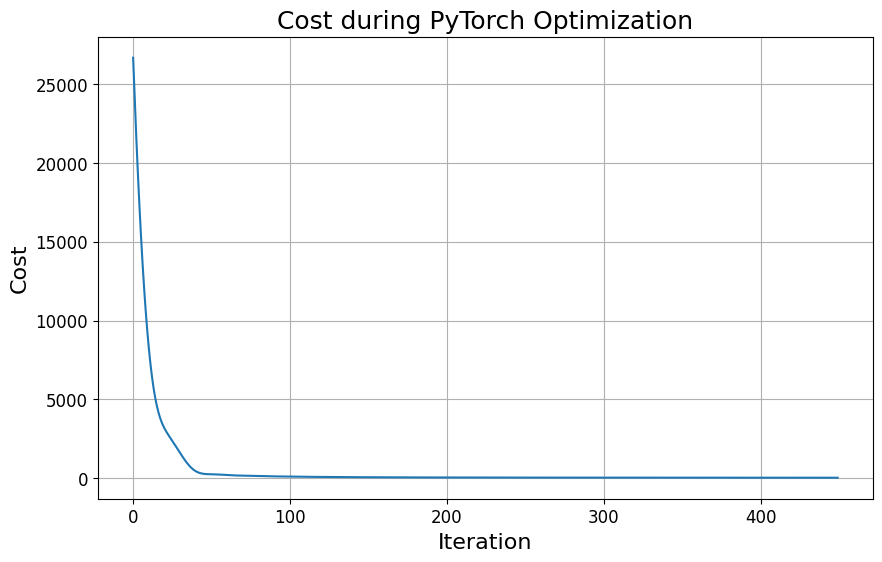

In [6]:
# Number of optimization iterations
num_iterations = 450 # Set a reasonable number of iterations for testing

print("Starting PyTorch optimization loop...")

# Store cost history for plotting (optional)
cost_history = []

# Ensure M1_init_torch and M2_init_torch are the parameters being optimized
# These should be in the (nx, ny, 3) shape with requires_grad=True
# The optimizer will treat them as flattened parameters internally
parameters_to_optimize = [M1_init_torch, M2_init_torch]
optimizer = torch.optim.AdamW(parameters_to_optimize, lr=0.01) # Re-instantiate optimizer with correct parameters. lr=0.01


for i in range(num_iterations):
    # Zero the gradients
    optimizer.zero_grad()

    # Calculate the cost
    # The cost function expects (3, N) shaped tensors.
    # We need to flatten the (nx, ny, 3) tensors here for the cost calculation.
    M1_flat = M1_init_torch.view(-1, 3).T # Use view and .T (or permute)
    M2_flat = M2_init_torch.view(-1, 3).T

    cost = problem.cost(M1_flat, M2_flat)


    # Perform backpropagation
    cost.backward()

    # Update parameters
    optimizer.step()

    # Log the cost (optional)
    if (i + 1) % 50 == 0 or i == 1: # Log first iteration and every 50
        print(f"Iteration {i+1}/{num_iterations}, Cost: {cost.item():.4e}")
    cost_history.append(cost.item())


print("Optimization loop finished.")

# After optimization, the optimized parameters are in M1_init_torch and M2_init_torch
# These are still in their original (nx, ny, 3) shape, modified by the optimizer.
# We can now use these directly as the optimized grid tensors.
M1_grid_opt_torch = M1_init_torch
M2_grid_opt_torch = M2_init_torch

# No need to reshape here if the initial tensors (M1_init_torch, M2_init_torch) were already (nx, ny, 3)
# If they were flattened initially and passed to the optimizer, we would reshape them here.

# Plotting the cost history
plt.figure(figsize=(10, 6))
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost during PyTorch Optimization')
plt.grid(True)
plt.show()

In [ ]:
# @title
#Field mismatch
print(3.5e17*torch.sum((B1_init - B2_init)**2))
#Topology
Q1 = problem.compute_skyrmion_number_torch(M1_init_torch)
Q2 = problem.compute_skyrmion_number_torch(M2_init_torch)
cost_topology = 15000.33333e-2 * (torch.abs(Q1 - Q2) - 0.5)**2
print(cost_topology)
#Tikhonov
grad_M1 = problem.spatial_gradient(M1_init_torch)
grad_M2 = problem.spatial_gradient(M2_init_torch)
cost_smoothness = 1e-18 * (torch.sum(grad_M1**2) + torch.sum(grad_M2**2))
print(cost_smoothness)


tensor(26681.2109, grad_fn=<MulBackward0>)
tensor(0.0018, dtype=torch.float64, grad_fn=<MulBackward0>)
tensor(10.3964, dtype=torch.float64, grad_fn=<MulBackward0>)


Skyrmion charge for M1 (optimized, Torch): -1.01
Skyrmion charge for M2 (optimized, Torch): -0.51
Average magnitude of optimized M1: 6.56e-01
Average magnitude of optimized M2: 1.04e+00
|M1| range: [0.334, 0.921]
|M2| range: [0.639, 1.432]


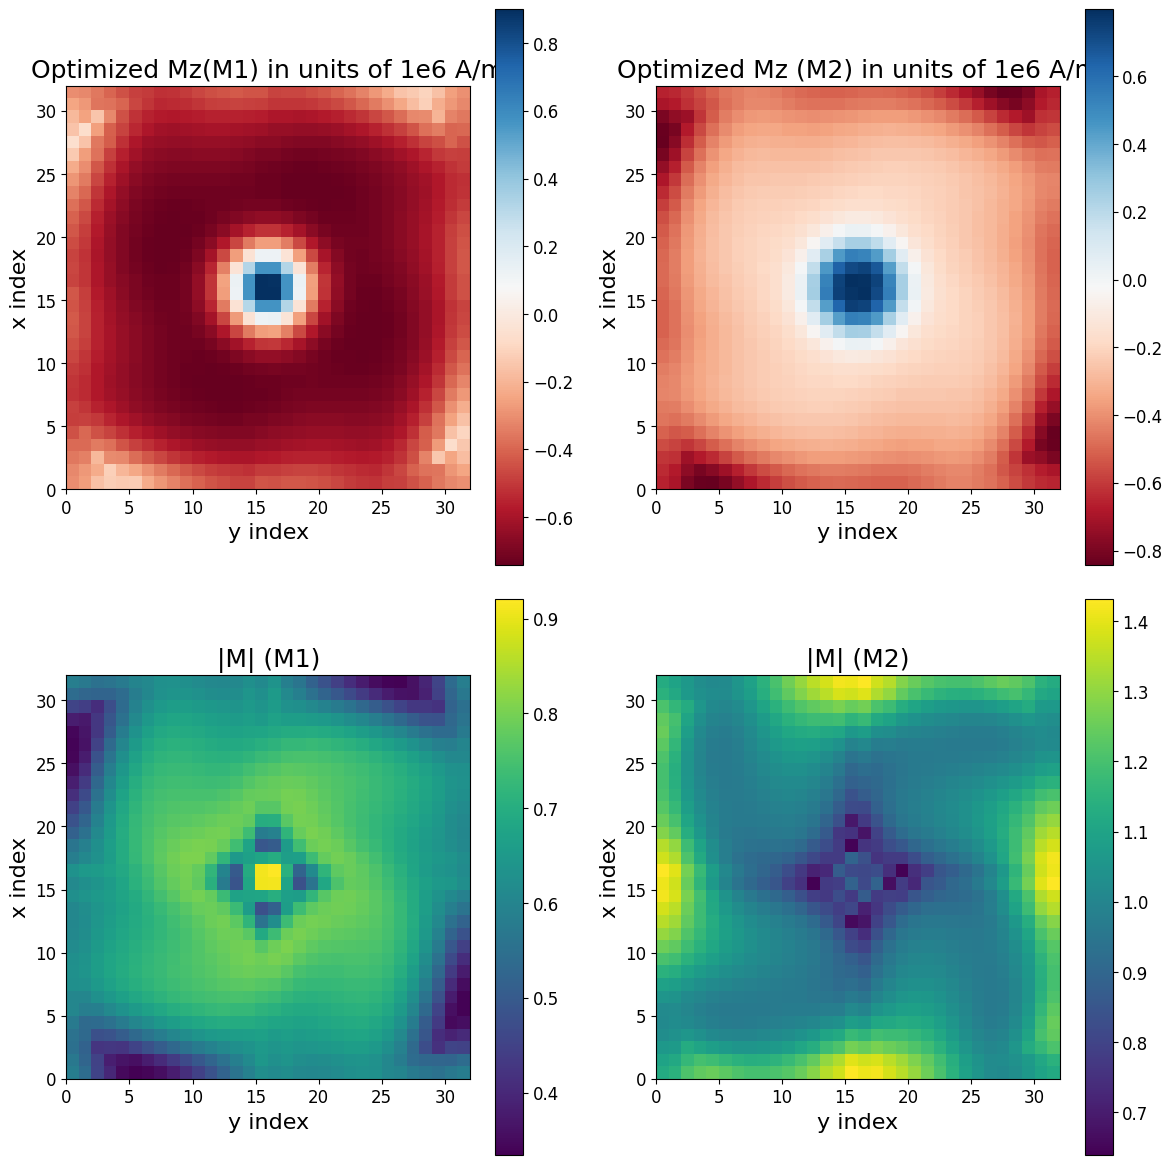

Optimized Mz plots and Magnetization Magnitude heatmaps generated.


In [7]:
# @title Plot Optimized Mz, Skyrmion Numbers, and Magnetization Magnitude Heatmaps

import matplotlib.pyplot as plt
import numpy as np
import torch

# Assuming M1_init_torch and M2_init_torch contain the optimized parameters
# and 'problem' is available from earlier cells.

# The optimized parameters are in M1_init_torch and M2_init_torch after the optimization cell (eb2c1bd3).
# They are already Torch tensors and in the grid shape (nx, ny, 3).
M1_grid_opt_torch = M1_init_torch
M2_grid_opt_torch = M2_init_torch

# Compute and print the skyrmion numbers for the optimized magnetizations using the Torch method
Q1_opt_torch = problem.compute_skyrmion_number_torch(M1_grid_opt_torch)
Q2_opt_torch = problem.compute_skyrmion_number_torch(M2_grid_opt_torch)

print(f"Skyrmion charge for M1 (optimized, Torch): {Q1_opt_torch.item():.2f}")
print(f"Skyrmion charge for M2 (optimized, Torch): {Q2_opt_torch.item():.2f}")


# Calculate the magnitude of the optimized magnetizations
M1_opt_magnitudes = torch.linalg.norm(M1_grid_opt_torch, dim=2)
M2_opt_magnitudes = torch.linalg.norm(M2_grid_opt_torch, dim=2)

# Calculate and print the average magnitude
average_M1_opt_magnitude = torch.mean(M1_opt_magnitudes)
average_M2_opt_magnitude = torch.mean(M2_opt_magnitudes)

print(f"Average magnitude of optimized M1: {average_M1_opt_magnitude.item():.2e}")
print(f"Average magnitude of optimized M2: {average_M2_opt_magnitude.item():.2e}")

print(f"|M1| range: [{M1_grid_opt_torch.norm(dim=-1).min():.3f}, {M1_grid_opt_torch.norm(dim=-1).max():.3f}]")
print(f"|M2| range: [{M2_grid_opt_torch.norm(dim=-1).min():.3f}, {M2_grid_opt_torch.norm(dim=-1).max():.3f}]")


# Convert the magnitude tensors to NumPy for plotting
M1_opt_magnitudes_np = M1_opt_magnitudes.detach().cpu().numpy()
M2_opt_magnitudes_np = M2_opt_magnitudes.detach().cpu().numpy()

# Convert the reshaped grid Torch tensors to NumPy for Mz plotting
M1_grid_opt_np = M1_grid_opt_torch.detach().cpu().numpy()
M2_grid_opt_np = M2_grid_opt_torch.detach().cpu().numpy()


# Plot Mz components and Magnetization Magnitudes
fig, axes = plt.subplots(2, 2, figsize=(12, 12)) # Changed to 2 rows, 2 columns


# Plot Optimized Mz components (Row 0)
im1 = axes[0, 0].imshow(M1_grid_opt_np[:, :, 2], origin='lower', cmap='RdBu', extent=[0, problem.ny, 0, problem.nx])
axes[0, 0].set_title('Optimized Mz(M1) in units of 1e6 A/m')
axes[0, 0].set_xlabel('y index')
axes[0, 0].set_ylabel('x index')
fig.colorbar(im1, ax=axes[0, 0])

im2 = axes[0, 1].imshow(M2_grid_opt_np[:, :, 2], origin='lower', cmap='RdBu', extent=[0, problem.ny, 0, problem.nx])
axes[0, 1].set_title('Optimized Mz (M2) in units of 1e6 A/m')
axes[0, 1].set_xlabel('y index')
axes[0, 1].set_ylabel('x index')
fig.colorbar(im2, ax=axes[0, 1])


# Plot Magnetization Magnitude Heatmaps (Row 1)
im3 = axes[1, 0].imshow(M1_opt_magnitudes_np, origin='lower', cmap='viridis', extent=[0, problem.ny, 0, problem.nx])
axes[1, 0].set_title('|M| (M1)')
axes[1, 0].set_xlabel('y index')
axes[1, 0].set_ylabel('x index')
fig.colorbar(im3, ax=axes[1, 0])

im4 = axes[1, 1].imshow(M2_opt_magnitudes_np, origin='lower', cmap='viridis', extent=[0, problem.ny, 0, problem.nx])
axes[1, 1].set_title('|M| (M2)')
axes[1, 1].set_xlabel('y index')
axes[1, 1].set_ylabel('x index')
fig.colorbar(im4, ax=axes[1, 1])


plt.tight_layout()
plt.show()

print("Optimized Mz plots and Magnetization Magnitude heatmaps generated.")

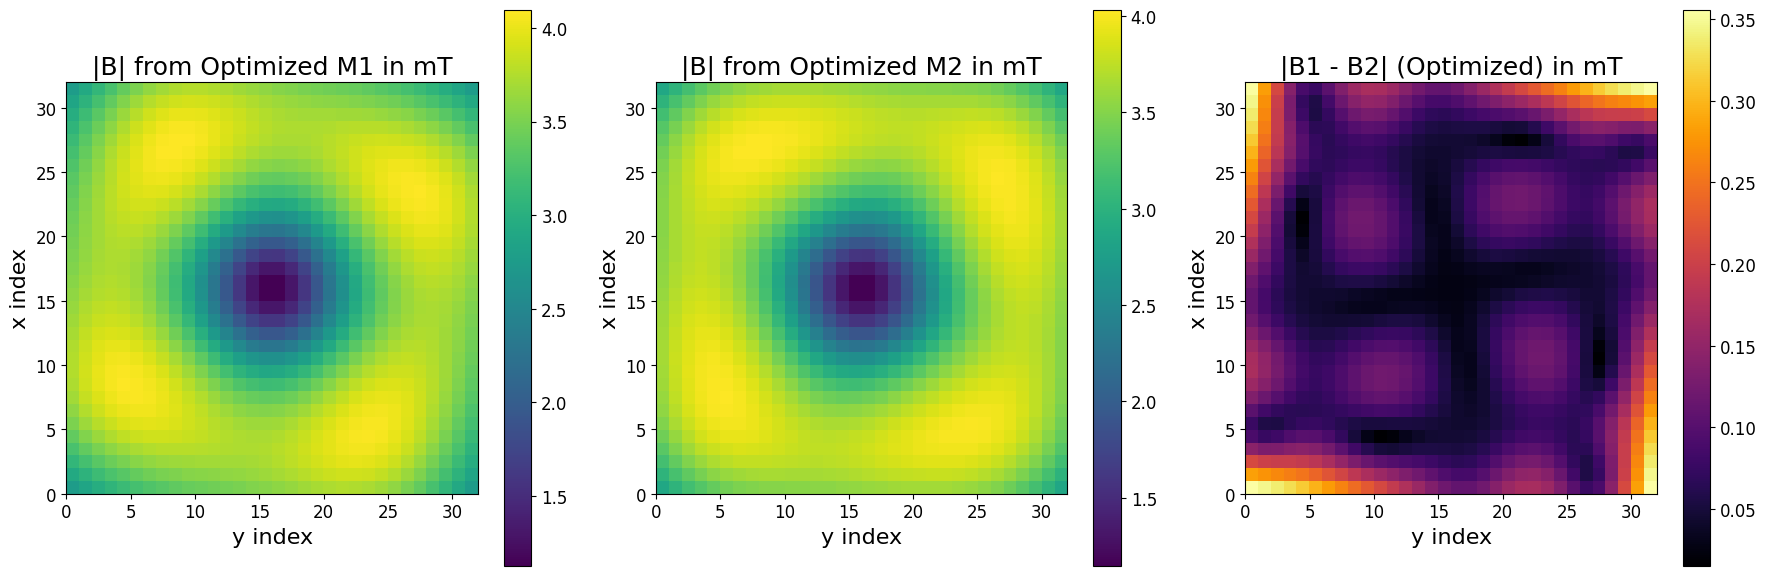

Root Mean Square Error (RMSE) between B1_final and B2_final: 6.84e-11 T
Average B field magnitude for normalization: 3.47e-09 T
Normalized Root Mean Square Error (NRMSE): 0.0197


In [8]:
# @title Plotting Optimized B Field Magnitudes and Difference

import matplotlib.pyplot as plt
import numpy as np
import torch

# Assuming problem, M1_init_torch, M2_init_torch are available from previous cells
# M1_init_torch and M2_init_torch should contain the optimized parameters after the optimization cell (eb2c1bd3)


# The optimized parameters are in M1_init_torch and M2_init_torch after optimization.
# They are already Torch tensors and in the grid shape (nx, ny, 3).
M1_grid_opt_torch = M1_init_torch
M2_grid_opt_torch = M2_init_torch


# Compute B fields (needed for B field plots)
B1_final = problem.compute_B_field(M1_grid_opt_torch)
B2_final = problem.compute_B_field(M2_grid_opt_torch)


# Convert Torch tensors to NumPy for plotting
B1_final_np = B1_final.detach().cpu().numpy()
B2_final_np = B2_final.detach().cpu().numpy()

# Calculate B field magnitudes and difference magnitude for plotting
B1_mag_np = np.linalg.norm(B1_final_np, axis=-1)
B2_mag_np = np.linalg.norm(B2_final_np, axis=-1)

# Calculate B field difference and its magnitude
B_diff_np = B1_final_np - B2_final_np
B_diff_mag_np = np.linalg.norm(B_diff_np, axis=-1)


nx, ny = problem.grid_shape
X, Y = np.meshgrid(np.arange(nx), np.arange(ny), indexing='ij')


fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Adjusted for 1 row, 3 columns


# Plot B field magnitudes and difference
im3 = axes[0].imshow(B1_mag_np*1e9, origin='lower', cmap='viridis', extent=[0, ny, 0, nx])
axes[0].set_title('|B| from Optimized M1 in mT')
axes[0].set_xlabel('y index')
axes[0].set_ylabel('x index')
fig.colorbar(im3, ax=axes[0])

im4 = axes[1].imshow(B2_mag_np*1e9, origin='lower', cmap='viridis', extent=[0, ny, 0, nx])
axes[1].set_title('|B| from Optimized M2 in mT')
axes[1].set_xlabel('y index')
axes[1].set_ylabel('x index')
fig.colorbar(im4, ax=axes[1])

im5 = axes[2].imshow(B_diff_mag_np*1e9, origin='lower', cmap='inferno', extent=[0, ny, 0, nx])
axes[2].set_title('|B1 - B2| (Optimized) in mT')
axes[2].set_xlabel('y index')
axes[2].set_ylabel('x index')
fig.colorbar(im5, ax=axes[2])


plt.tight_layout()
plt.show()

# Calculate the difference between the final B fields
B_diff = B1_final - B2_final

# Calculate the squared difference
B_diff_squared = B_diff**2

# Calculate the mean squared error (MSE) over all components and grid points
mse = torch.mean(B_diff_squared)

# Calculate the Root Mean Squared Error (RMSE)
rmse = torch.sqrt(mse)

# Calculate the average magnitude of the final B fields for normalization
average_B_magnitude = torch.mean(torch.linalg.norm(B1_final, dim=-1) + torch.linalg.norm(B2_final, dim=-1)) / 2.0

# Avoid division by zero if average magnitude is very small
epsilon = 1e-12
normalization_factor = torch.maximum(average_B_magnitude, torch.tensor(epsilon))

# Calculate the Normalized Root Mean Square Error (NRMSE)
nrmse = rmse / normalization_factor

print(f"Root Mean Square Error (RMSE) between B1_final and B2_final: {rmse.item():.2e} T")
print(f"Average B field magnitude for normalization: {normalization_factor.item():.2e} T")
print(f"Normalized Root Mean Square Error (NRMSE): {nrmse.item():.4f}")

**Component wise stray field plotting of final optimized textures**

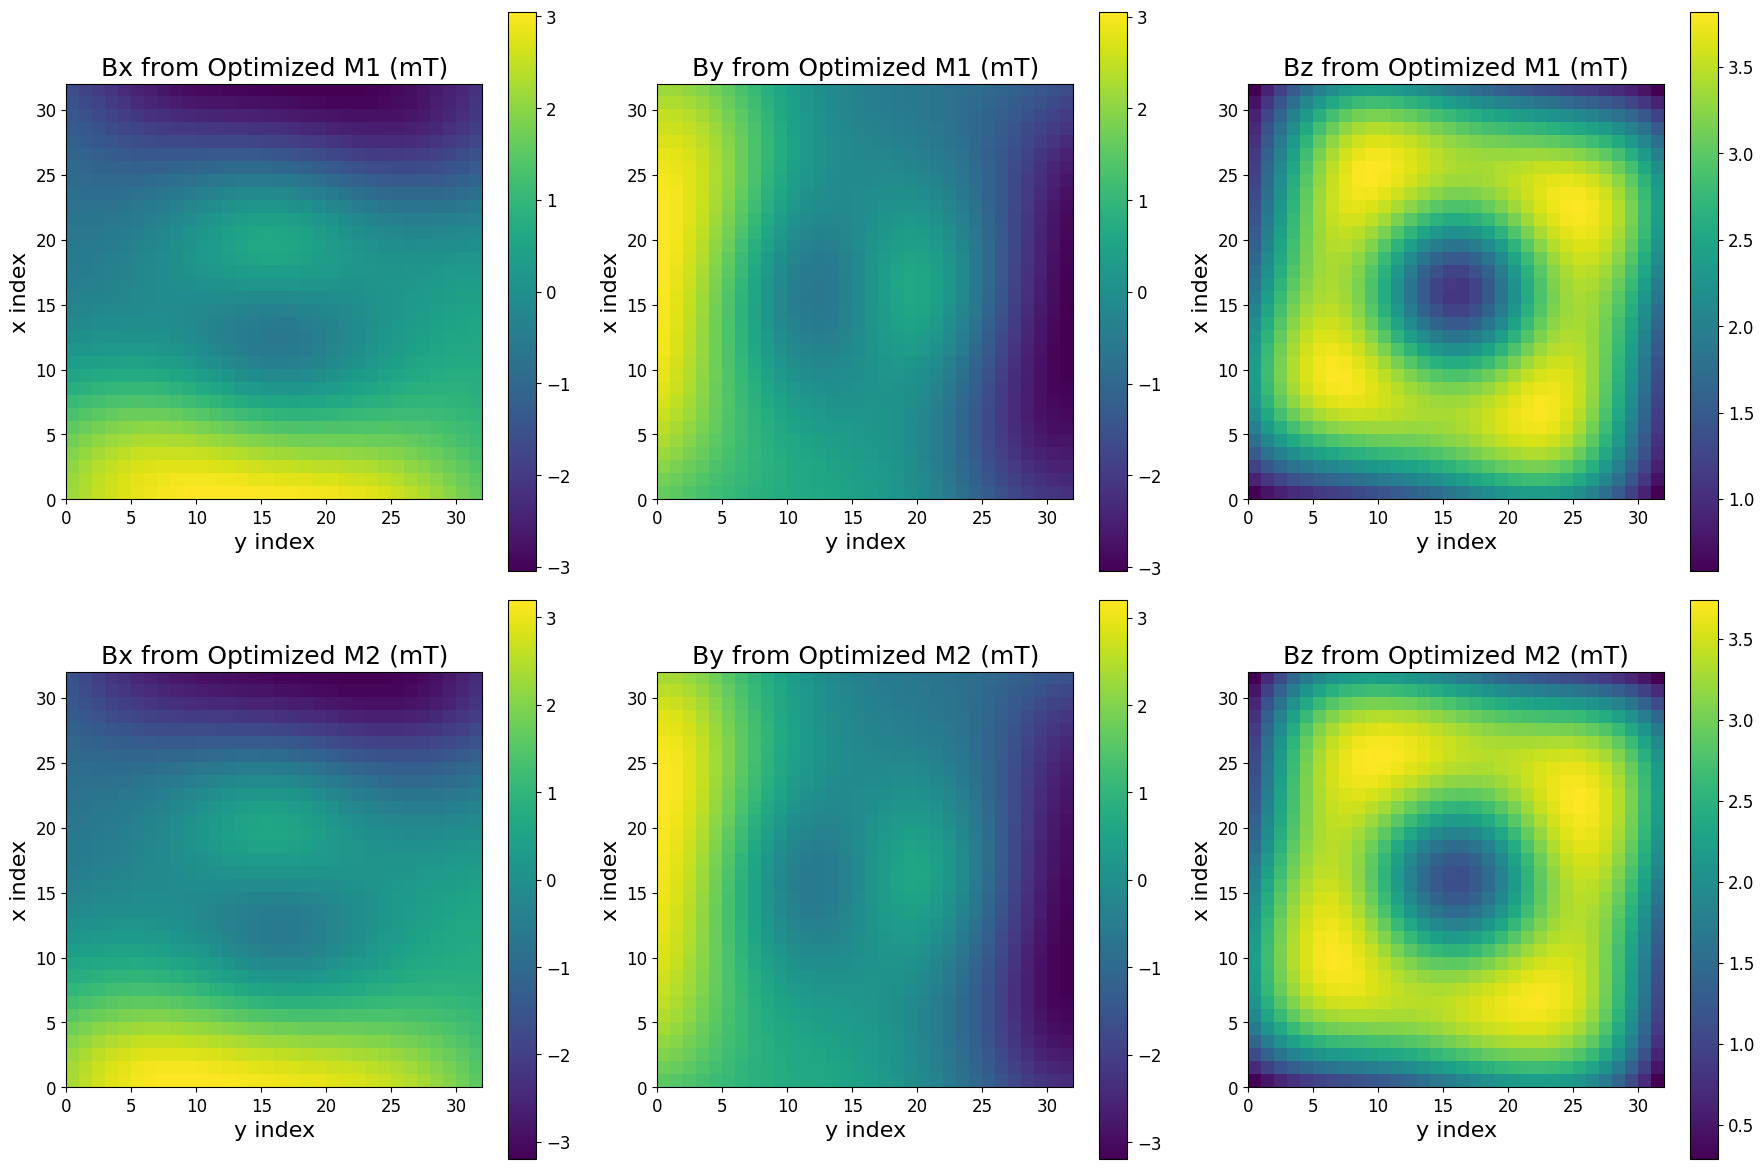

Individual B-field components (Bx, By, Bz) plotted for both optimized magnetizations.


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Assuming B1_final and B2_final are available from previous cells
# These are Torch tensors in the grid shape (nx, ny, 3)

nx, ny = problem.grid_shape

fig, axes = plt.subplots(2, 3, figsize=(18, 12)) # 2 rows (for M1, M2), 3 columns (for Bx, By, Bz)

# Plot Bx, By, Bz for M1
im1_bx = axes[0, 0].imshow(B1_final_np[:, :, 0]*1e9, origin='lower', cmap='viridis', extent=[0, ny, 0, nx])
axes[0, 0].set_title('Bx from Optimized M1 (mT)')
axes[0, 0].set_xlabel('y index')
axes[0, 0].set_ylabel('x index')
fig.colorbar(im1_bx, ax=axes[0, 0])

im1_by = axes[0, 1].imshow(B1_final_np[:, :, 1]*1e9, origin='lower', cmap='viridis', extent=[0, ny, 0, nx])
axes[0, 1].set_title('By from Optimized M1 (mT)')
axes[0, 1].set_xlabel('y index')
axes[0, 1].set_ylabel('x index')
fig.colorbar(im1_by, ax=axes[0, 1])

im1_bz = axes[0, 2].imshow(B1_final_np[:, :, 2]*1e9, origin='lower', cmap='viridis', extent=[0, ny, 0, nx])
axes[0, 2].set_title('Bz from Optimized M1 (mT)')
axes[0, 2].set_xlabel('y index')
axes[0, 2].set_ylabel('x index')
fig.colorbar(im1_bz, ax=axes[0, 2])

# Plot Bx, By, Bz for M2
im2_bx = axes[1, 0].imshow(B2_final_np[:, :, 0]*1e9, origin='lower', cmap='viridis', extent=[0, ny, 0, nx])
axes[1, 0].set_title('Bx from Optimized M2 (mT)')
axes[1, 0].set_xlabel('y index')
axes[1, 0].set_ylabel('x index')
fig.colorbar(im2_bx, ax=axes[1, 0])

im2_by = axes[1, 1].imshow(B2_final_np[:, :, 1]*1e9, origin='lower', cmap='viridis', extent=[0, ny, 0, nx])
axes[1, 1].set_title('By from Optimized M2 (mT)')
axes[1, 1].set_xlabel('y index')
axes[1, 1].set_ylabel('x index')
fig.colorbar(im2_by, ax=axes[1, 1])

im2_bz = axes[1, 2].imshow(B2_final_np[:, :, 2]*1e9, origin='lower', cmap='viridis', extent=[0, ny, 0, nx])
axes[1, 2].set_title('Bz from Optimized M2 (mT)')
axes[1, 2].set_xlabel('y index')
axes[1, 2].set_ylabel('x index')
fig.colorbar(im2_bz, ax=axes[1, 2])

plt.tight_layout()
plt.show()

print("Individual B-field components (Bx, By, Bz) plotted for both optimized magnetizations.")

## Multi Pole Analysis

In [11]:
import numpy as np
from scipy.special import factorial

def compute_cartesian_moments(mz, x2d, y2d, order_max):
    """
    Compute Cartesian multipole moments of σ_eff = mz(x,y).
    M_pq = ∫∫ x^p * y^q * mz(x,y) dx dy

    These are the natural basis for 2D thin-film magnetostatics.
    Total order l = p + q ranges from 0 to order_max.
    """
    dx = x2d[0,1] - x2d[1,1]
    dA = dx**2

    moments = {}
    for p in range(order_max + 1):
        for q in range(order_max + 1 - p):
            M_pq = np.sum((x2d**p) * (y2d**q) * mz) * dA
            moments[(p, q)] = M_pq
    return moments

def print_moment_comparison(mom1, mom2, order_max):
    print(f"{'(p,q)':<8} {'l=p+q':<8} {'M1':<14} {'M2':<14} {'|ΔM|/avg':<12}")
    print("-" * 58)
    for l in range(order_max + 1):
        for p in range(l + 1):
            q = l - p
            M1 = mom1[(p,q)]
            M2 = mom2[(p,q)]
            avg = 0.5 * (abs(M1) + abs(M2))
            rel = abs(M1 - M2) / (avg + 1e-30)
            print(f"({p},{q})    {l:<8} {M1:<14.4e} {M2:<14.4e} {rel:<12.4f}")
        print()  # blank line between orders

# Center each texture by shifting the center of mass of |mz| to the grid center
def center_texture(mz):
    from scipy.ndimage import shift
    total = np.abs(mz).sum()
    cx = (np.abs(mz) * np.arange(mz.shape[0])[:,None]).sum() / total
    cy = (np.abs(mz) * np.arange(mz.shape[1])[None,:]).sum() / total
    shift_x = mz.shape[0]//2 - cx
    shift_y = mz.shape[1]//2 - cy
    return shift(mz, [shift_x, shift_y], mode='wrap')

def print_moment_comparison_parity(mom1, mom2, order_max=8):
    """
    Print only even-parity moments (p+q even, both p and q even).
    These are the physically meaningful ones for axisymmetric-ish textures
    and don't blow up due to centering issues.
    """
    print(f"{'(p,q)':<8} {'l=p+q':<8} {'M1':<14} {'M2':<14} {'|ΔM|/avg':<12}")
    print("-" * 58)
    for l in range(0, order_max + 1, 2):  # even orders only
        for p in range(0, l + 1, 2):      # even p only
            q = l - p
            if q % 2 != 0:
                continue                   # even q only
            M1 = mom1[(p,q)]
            M2 = mom2[(p,q)]
            avg = 0.5 * (abs(M1) + abs(M2))
            rel = abs(M1 - M2) / (avg + 1e-30)
            print(f"({p},{q})    {l:<8} {M1:<14.4e} {M2:<14.4e} {rel:<12.4f}")
        print()

In [ ]:
# @title
print(M1_grid_opt_torch[:,:,2])
print(M2_grid_opt_torch[:,:,2])

tensor([[-0.1040, -0.1061, -0.1418,  ..., -0.1834, -0.1120, -0.1024],
        [-0.1137, -0.1166, -0.1533,  ..., -0.1889, -0.1139, -0.1043],
        [-0.1857, -0.1920, -0.2227,  ..., -0.2245, -0.1525, -0.1402],
        ...,
        [-0.1251, -0.1366, -0.2254,  ..., -0.2293, -0.1939, -0.1884],
        [-0.1020, -0.1117, -0.1850,  ..., -0.1565, -0.1191, -0.1168],
        [-0.0979, -0.1073, -0.1811,  ..., -0.1451, -0.1094, -0.1073]],
       dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor([[-0.6537, -0.6506, -0.6222,  ..., -0.5702, -0.6422, -0.6512],
        [-0.6446, -0.6412, -0.6119,  ..., -0.5658, -0.6388, -0.6482],
        [-0.5723, -0.5679, -0.5344,  ..., -0.5324, -0.6097, -0.6201],
        ...,
        [-0.6162, -0.6060, -0.5291,  ..., -0.5371, -0.5712, -0.5756],
        [-0.6441, -0.6347, -0.5619,  ..., -0.6147, -0.6448, -0.6483],
        [-0.6470, -0.6380, -0.5662,  ..., -0.6251, -0.6544, -0.6575]],
       dtype=torch.float64, grad_fn=<SelectBackward0>)


**Do Multi pole comparison**

In [12]:
# Build coordinate grids (centered, normalized to [-0.5, 0.5])
nx, ny = M1_grid_opt_torch.shape[:2]
print(nx,ny)
x_norm = np.linspace(-0.5, 0.5, nx)
y_norm = np.linspace(-0.5, 0.5, ny)
x2d, y2d = np.meshgrid(x_norm, y_norm, indexing='ij')
#print(x2d,y2d)
#print(x2d[1,1])# - x2d[0,0])

# Extract mz (detach, no unit scaling needed — moments are dimensionless)
mz1 = M1_grid_opt_torch[:,:,2].cpu().detach().numpy()
mz2 = M2_grid_opt_torch[:,:,2].cpu().detach().numpy()

mz1_centered = center_texture(mz1)
mz2_centered = center_texture(mz2)

# Compute and compare
mom1 = compute_cartesian_moments(mz1, x2d, y2d, order_max=8)
#print (mom1)
mom2 = compute_cartesian_moments(mz2, x2d, y2d, order_max=8)
#print(mom2)
print_moment_comparison_parity(mom1, mom2, order_max=8)

32 32
(p,q)    l=p+q    M1             M2             |ΔM|/avg    
----------------------------------------------------------
(0,0)    0        -5.8296e-01    -3.2611e-01    0.5651      

(0,2)    2        -4.8115e-02    -4.1369e-02    0.1508      
(2,0)    2        -4.8124e-02    -4.1366e-02    0.1510      

(0,4)    4        -7.0286e-03    -7.3329e-03    0.0424      
(2,2)    4        -3.5261e-03    -4.4696e-03    0.2360      
(4,0)    4        -7.0319e-03    -7.3323e-03    0.0418      

(0,6)    6        -1.2566e-03    -1.4678e-03    0.1550      
(2,4)    6        -5.0524e-04    -7.7030e-04    0.4156      
(4,2)    6        -5.0552e-04    -7.7028e-04    0.4150      
(6,0)    6        -1.2576e-03    -1.4676e-03    0.1542      

(0,8)    8        -2.4903e-04    -3.1265e-04    0.2265      
(2,6)    8        -9.0015e-05    -1.5183e-04    0.5112      
(4,4)    8        -7.2414e-05    -1.3106e-04    0.5764      
(6,2)    8        -9.0118e-05    -1.5183e-04    0.5101      
(8,0)    8      

## Monte Carlo Sampling

In [13]:
# 1. Define the number of Monte Carlo samples
num_monte_carlo_samples = 100

# 2. Define the available magnetization texture types
texture_types = ['skyrmion', 'vortex', 'uniform_inplane', 'fractional_Q']

# 3. Define the perturbation strength
perturbation_strength = 0.01

# Parameters for random variation within each texture type will be handled later in the loop.
# For now, just define the overall sampling parameters.

In [14]:
import random
import torch # Import torch as it's used in the problem definition
import numpy as np # Import numpy for numpy operations

# Lists to store results
initial_q_diffs = []
final_q_diffs = []
initial_nrmse_values = []
final_nrmse_values = []
high_nrmse_results = [] # Modified to store (texture1_type, texture2_type, final_nrmse)

# Lists to store parameters for later analysis (as requested)
texture1_types_list = []
texture2_types_list = []
texture1_params_list = []
texture2_params_list = []

#Average magnetization magnitudes of final optimized textures. To check the algorithm is not finding trivial solutions
final_mag_magnitudes_1 = []  # For texture 1 (M1_grid_opt_torch)
final_mag_magnitudes_2 = []  # For texture 2 (M2_grid_opt_torch)


# Define the problem instance before the loop
# Assuming AmbiguousMagnetizationFree class is defined in a previous cell
problem = AmbiguousMagnetizationFree(
    grid_shape=(32, 32),
    dx=2e-9, dy=2e-9,
    thickness=1e-9, height=20e-9, # Set height to 20e-9
    Ms=1 # Set Ms=1 here
)

# Start the Monte Carlo loop
print(f"Starting Monte Carlo sampling with {num_monte_carlo_samples} samples...")

for i in range(num_monte_carlo_samples):
    # Randomly select two distinct texture types
    #texture1_type = random.choice(texture_types)
    texture1_type = 'skyrmion'
    #texture1_type = 'vortex'
    #texture1_type = 'uniform_inplane'
    #texture1_type = 'fractional_Q'
    # Ensure texture2 is different from texture1
    #texture2_type = 'fractional_Q'
    #texture2_type = 'uniform_inplane'
    #texture2_type = 'vortex'
    #texture2_type = 'skyrmion
    texture2_type = random.choice([t for t in texture_types if t != texture1_type])

    # Randomly select parameters based on texture type
    if texture1_type == 'skyrmion' or texture1_type == 'vortex' or texture1_type == 'fractional_Q':
        texture1_param = random.choice([1, -1]) # sign
    elif texture1_type == 'uniform_inplane':
        texture1_param = random.uniform(0, 360) # angle in degrees

    if texture2_type == 'skyrmion' or texture2_type == 'vortex' or texture2_type == 'fractional_Q':
        texture2_param = random.choice([1, -1]) # sign
    elif texture2_type == 'uniform_inplane':
        texture2_param = random.uniform(0, 360) # angle in degrees

    # Store parameters
    texture1_types_list.append(texture1_type)
    texture2_types_list.append(texture2_type)
    texture1_params_list.append(texture1_param)
    texture2_params_list.append(texture2_param)

    # Print progress (optional)
    if (i + 1) % 50 == 0:
        print(f"Processing sample {i+1}/{num_monte_carlo_samples}")

    # Inside the Monte Carlo loop (from previous cell)
    # Generate initial magnetization states based on selected types and parameters
    if texture1_type == 'skyrmion':
        M1_init_np = generate_skyrmion(problem.nx, problem.ny, Ms=problem.Ms, sign=texture1_param).numpy()
    elif texture1_type == 'vortex':
        M1_init_np = generate_vortex(problem.nx, problem.ny, Ms=problem.Ms, sign=texture1_param).numpy()
    elif texture1_type == 'uniform_inplane':
        M1_init_np = generate_uniform_inplane(problem.nx, problem.ny, Ms=problem.Ms, angle_deg=texture1_param).numpy()
    elif texture1_type == 'fractional_Q':
        M1_init_np = generate_fractional_Q(problem.nx, problem.ny, Ms=problem.Ms, sign=texture1_param).numpy()
    else:
        raise ValueError(f"Unknown texture type: {texture1_type}")

    if texture2_type == 'skyrmion':
        M2_init_np = generate_skyrmion(problem.nx, problem.ny, Ms=problem.Ms, sign=texture2_param).numpy()
    elif texture2_type == 'vortex':
        M2_init_np = generate_vortex(problem.nx, problem.ny, Ms=problem.Ms, sign=texture2_param).numpy()
    elif texture2_type == 'uniform_inplane':
        M2_init_np = generate_uniform_inplane(problem.nx, problem.ny, Ms=problem.Ms, angle_deg=texture2_param).numpy()
    elif texture2_type == 'fractional_Q':
        M2_init_np = generate_fractional_Q(problem.nx, problem.ny, Ms=problem.Ms, sign=texture2_param).numpy()
    else:
        raise ValueError(f"Unknown texture type: {texture2_type}")

    # Convert to Torch tensors with requires_grad=True
    M1_init_torch = torch.tensor(M1_init_np, dtype=torch.float64, requires_grad=True)
    M2_init_torch = torch.tensor(M2_init_np, dtype=torch.float64, requires_grad=True)


    # Add a small random perturbation to the Torch tensors
    perturbation1 = torch.randn_like(M1_init_torch) * perturbation_strength
    perturbation2 = torch.randn_like(M2_init_torch) * perturbation_strength

    M1_perturbed_init = M1_init_torch + perturbation1
    M2_perturbed_init = M2_init_torch + perturbation2

    # Ensure the perturbed tensors are the ones used for optimization and calculations
    M1_current = M1_perturbed_init.clone().detach().requires_grad_(True)
    M2_current = M2_perturbed_init.clone().detach().requires_grad_(True)


    # Calculate initial B fields using the perturbed magnetizations
    B1_init = problem.compute_B_field(M1_current)
    B2_init = problem.compute_B_field(M2_current)

    # Calculate initial skyrmion numbers (using the Torch method)
    Q1_init = problem.compute_skyrmion_number_torch(M1_current)
    Q2_init = problem.compute_skyrmion_number_torch(M2_current)
    initial_q_diffs.append((Q1_init - Q2_init).item())

    # Calculate initial NRMSE
    B_diff_init = B1_init - B2_init
    rmse_init = torch.sqrt(torch.mean(B_diff_init**2))
    average_B_magnitude_init = torch.mean(torch.linalg.norm(B1_init, dim=-1) + torch.linalg.norm(B2_init, dim=-1)) / 2.0
    epsilon = 1e-12
    normalization_factor_init = torch.maximum(average_B_magnitude_init, torch.tensor(epsilon))
    nrmse_init = rmse_init / normalization_factor_init
    initial_nrmse_values.append(nrmse_init.item())

    # Optimization loop
    # Set up the optimizer inside the loop to optimize the current perturbed initial state
    parameters_to_optimize = [M1_current, M2_current]
    optimizer = torch.optim.AdamW(parameters_to_optimize, lr=0.01)
    num_iterations = 450 # Define num_iterations if not already

    for iter in range(num_iterations):
        optimizer.zero_grad()

        # The cost function expects (3, N) shaped tensors.
        M1_flat = M1_current.view(-1, 3).T
        M2_flat = M2_current.view(-1, 3).T

        cost = problem.cost(M1_flat, M2_flat)

        cost.backward()
        optimizer.step()

    # After optimization, M1_current and M2_current hold the optimized magnetizations
    M1_grid_opt_torch = M1_current
    M2_grid_opt_torch = M2_current

    # Calculate and store the mean magnetization magnitude for each optimized texture
    mag_magnitude_1 = torch.sqrt(torch.sum(M1_grid_opt_torch**2, dim=-1)).mean().item()
    final_mag_magnitudes_1.append(mag_magnitude_1)

    mag_magnitude_2 = torch.sqrt(torch.sum(M2_grid_opt_torch**2, dim=-1)).mean().item()
    final_mag_magnitudes_2.append(mag_magnitude_2)


    # Calculate final B fields using the optimized magnetizations
    B1_final = problem.compute_B_field(M1_grid_opt_torch)
    B2_final = problem.compute_B_field(M2_grid_opt_torch)

    # Calculate final skyrmion numbers
    Q1_opt_torch = problem.compute_skyrmion_number_torch(M1_grid_opt_torch)
    Q2_opt_torch = problem.compute_skyrmion_number_torch(M2_grid_opt_torch)
    final_q_diffs.append((Q1_opt_torch - Q2_opt_torch).item())

    # Calculate final NRMSE
    B_diff_final = B1_final - B2_final
    rmse_final = torch.sqrt(torch.mean(B_diff_final**2))
    average_B_magnitude_final = torch.mean(torch.linalg.norm(B1_final, dim=-1) + torch.linalg.norm(B2_final, dim=-1)) / 2.0
    normalization_factor_final = torch.maximum(average_B_magnitude_final, torch.tensor(epsilon))
    nrmse_final = rmse_final / normalization_factor_final
    final_nrmse_values.append(nrmse_final.item())

    # Store initial texture types and final NRMSE if final NRMSE >= 2%
    if nrmse_final.item() >= 0.02:
        high_nrmse_results.append((texture1_type, texture2_type, nrmse_final.item()))

# End of the Monte Carlo loop (closing the loop started in the previous cell)


Starting Monte Carlo sampling with 100 samples...
Processing sample 50/100
Processing sample 100/100


In [15]:
print(np.mean(final_nrmse_values))

0.030194273819215595


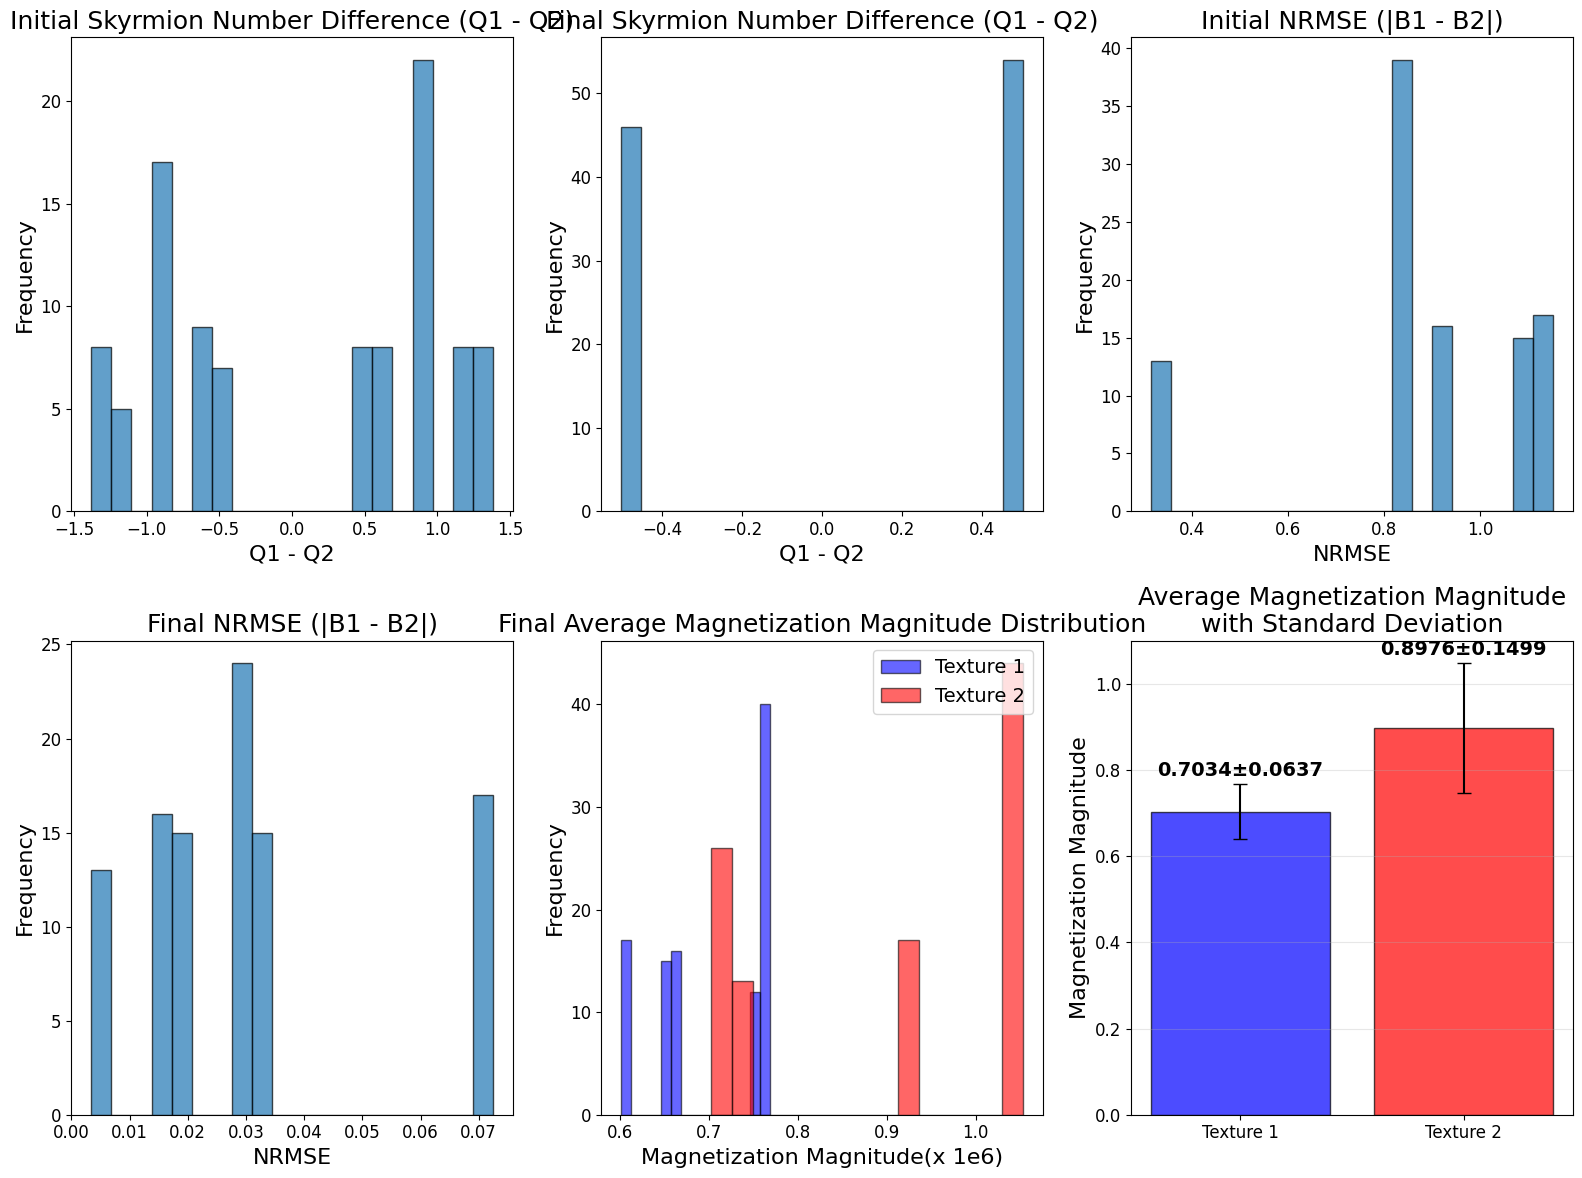

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate statistics
mag1_mean = np.mean(final_mag_magnitudes_1)
mag1_std = np.std(final_mag_magnitudes_1)
mag2_mean = np.mean(final_mag_magnitudes_2)
mag2_std = np.std(final_mag_magnitudes_2)

# Enhanced visualization: add to or replace your current block
plt.figure(figsize=(16, 12))

# (Optional) Keep your original histograms
plt.subplot(2, 3, 1)
plt.hist(initial_q_diffs, bins=20, edgecolor='black', alpha=0.7)
plt.title('Initial Skyrmion Number Difference (Q1 - Q2)')
plt.xlabel('Q1 - Q2')
plt.ylabel('Frequency')

plt.subplot(2, 3, 2)
plt.hist(final_q_diffs, bins=20, edgecolor='black', alpha=0.7)
plt.title('Final Skyrmion Number Difference (Q1 - Q2)')
plt.xlabel('Q1 - Q2')
plt.ylabel('Frequency')

plt.subplot(2, 3, 3)
plt.hist(initial_nrmse_values, bins=20, edgecolor='black', alpha=0.7)
plt.title('Initial NRMSE (|B1 - B2|)')
plt.xlabel('NRMSE')
plt.ylabel('Frequency')

plt.subplot(2, 3, 4)
plt.hist(final_nrmse_values, bins=20, edgecolor='black', alpha=0.7)
plt.title('Final NRMSE (|B1 - B2|)')
plt.xlabel('NRMSE')
plt.ylabel('Frequency')

# Histogram of magnetization magnitudes
plt.subplot(2, 3, 5)
plt.hist(final_mag_magnitudes_1, bins=15, alpha=0.6, label='Texture 1', color='blue', edgecolor='black')
plt.hist(final_mag_magnitudes_2, bins=15, alpha=0.6, label='Texture 2', color='red', edgecolor='black')
plt.title('Final Average Magnetization Magnitude Distribution')
plt.xlabel('Magnetization Magnitude(x 1e6)')
plt.ylabel('Frequency')
plt.legend()

# Bar plot: mean and std
plt.subplot(2, 3, 6)
textures = ['Texture 1', 'Texture 2']
means = [mag1_mean, mag2_mean]
stds = [mag1_std, mag2_std]
colors = ['blue', 'red']

bars = plt.bar(textures, means, yerr=stds, capsize=5, color=colors, alpha=0.7, edgecolor='black')
plt.title('Average Magnetization Magnitude\nwith Standard Deviation')
plt.ylabel('Magnetization Magnitude')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, (mean, std) in enumerate(zip(means, stds)):
    plt.text(i, mean + std + 0.01*max(means), f'{mean:.4f}±{std:.4f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## Meshing Sensitivity Analysis: How is the algorithm affected by finer meshes (we did 32 x 32 in the original paper)

In [17]:
grid_resolutions = [(32, 32), (64, 64), (128, 128)]
physical_sample_size_nm = (64, 64)

print(f"Grid resolutions to test: {grid_resolutions}")
print(f"Constant physical sample dimensions: {physical_sample_size_nm} nm")

Grid resolutions to test: [(32, 32), (64, 64), (128, 128)]
Constant physical sample dimensions: (64, 64) nm


In [18]:
import torch
import numpy as np

# --- Initialize lists to store results ---
all_final_nrmse = []
all_q_diff_abs = []
all_m1_avg_magnitudes = []
all_m2_avg_magnitudes = []

# --- Fixed parameters for the problem instance ---
thickness = 1e-9 # meters (film thickness)
fixed_height_B = 20e-9 # meters (20 nm standoff height for B-field calculation)
Ms = 1 # Ms=1 for optimization, scaling will be applied at plotting
device = 'cuda' if torch.cuda.is_available() else 'cpu'
num_optimization_iterations = 450 # Fixed number of iterations for the optimization loop

print(f"Running sensitivity analysis on device: {device}")

# --- Iterate through each grid resolution ---
for nx, ny in grid_resolutions:
    print(f"\n--- Processing resolution: {nx}x{ny} ---")

    # 1. Calculate dx and dy for the current resolution
    dx = physical_sample_size_nm[0] * 1e-9 / nx # Convert nm to meters
    dy = physical_sample_size_nm[1] * 1e-9 / ny # Convert nm to meters

    print(f"Calculated dx: {dx:.2e} m, dy: {dy:.2e} m")

    # 2. Re-initialize the AmbiguousMagnetizationFree problem instance
    problem = AmbiguousMagnetizationFree(
        grid_shape=(nx, ny),
        dx=dx, dy=dy,
        thickness=thickness, height=fixed_height_B,
        Ms=Ms
    )

    # 3. Generate initial magnetization patterns (skyrmion and vortex)
    M1_init_torch = generate_skyrmion(nx, ny, Ms=problem.Ms, device=device)
    M2_init_torch = generate_vortex(nx, ny, Ms=problem.Ms, device=device)

    # Ensure tensors have requires_grad=True
    M1_current = M1_init_torch.to(dtype=torch.float64, device=device).requires_grad_(True)
    M2_current = M2_init_torch.to(dtype=torch.float64, device=device).requires_grad_(True)

    # 4. Initialize an AdamW optimizer
    parameters_to_optimize = [M1_current, M2_current]
    optimizer = torch.optim.AdamW(parameters_to_optimize, lr=0.01)

    # 5. Execute optimization loop
    for iter_idx in range(num_optimization_iterations):
        optimizer.zero_grad()

        # Reshape M1 and M2 for the cost function
        M1_flat = M1_current.view(-1, 3).T
        M2_flat = M2_current.view(-1, 3).T

        cost = problem.cost(M1_flat, M2_flat)

        cost.backward()
        optimizer.step()

    print(f"Optimization finished for {nx}x{ny} resolution. Final Cost: {cost.item():.4e}")

    # 6. Compute and store final metrics
    # Compute final B-fields
    B1_final = problem.compute_B_field(M1_current)
    B2_final = problem.compute_B_field(M2_current)

    # Calculate NRMSE
    B_diff_final = B1_final - B2_final
    rmse_final = torch.sqrt(torch.mean(B_diff_final**2))
    average_B_magnitude_final = torch.mean(torch.linalg.norm(B1_final, dim=-1) + torch.linalg.norm(B2_final, dim=-1)) / 2.0
    epsilon = 1e-12
    normalization_factor_final = torch.maximum(average_B_magnitude_final, torch.tensor(epsilon, device=device))
    nrmse_final = rmse_final / normalization_factor_final
    all_final_nrmse.append(nrmse_final.item())
    print(f"Final NRMSE: {nrmse_final.item():.4f}")

    # Compute final skyrmion numbers
    Q1_opt = problem.compute_skyrmion_number_torch(M1_current)
    Q2_opt = problem.compute_skyrmion_number_torch(M2_current)
    q_diff_abs = torch.abs(Q1_opt - Q2_opt)
    all_q_diff_abs.append(q_diff_abs.item())
    print(f"Final |Q1 - Q2|: {q_diff_abs.item():.4f}")

    # Calculate average magnitudes of optimized M1 and M2
    m1_avg_mag = torch.mean(torch.linalg.norm(M1_current, dim=2))
    m2_avg_mag = torch.mean(torch.linalg.norm(M2_current, dim=2))
    all_m1_avg_magnitudes.append(m1_avg_mag.item())
    all_m2_avg_magnitudes.append(m2_avg_mag.item())
    print(f"Avg |M1|: {m1_avg_mag.item():.4f}, Avg |M2|: {m2_avg_mag.item():.4f}")

print("\n--- Sensitivity analysis complete ---")

Running sensitivity analysis on device: cpu

--- Processing resolution: 32x32 ---
Calculated dx: 2.00e-09 m, dy: 2.00e-09 m
Optimization finished for 32x32 resolution. Final Cost: 1.5448e+01
Final NRMSE: 0.0197
Final |Q1 - Q2|: 0.4966
Avg |M1|: 0.6557, Avg |M2|: 1.0450

--- Processing resolution: 64x64 ---
Calculated dx: 1.00e-09 m, dy: 1.00e-09 m
Optimization finished for 64x64 resolution. Final Cost: 6.1443e+01
Final NRMSE: 0.0197
Final |Q1 - Q2|: 0.4958
Avg |M1|: 0.6550, Avg |M2|: 1.0446

--- Processing resolution: 128x128 ---
Calculated dx: 5.00e-10 m, dy: 5.00e-10 m
Optimization finished for 128x128 resolution. Final Cost: 2.4599e+02
Final NRMSE: 0.0197
Final |Q1 - Q2|: 0.4911
Avg |M1|: 0.6551, Avg |M2|: 1.0444

--- Sensitivity analysis complete ---


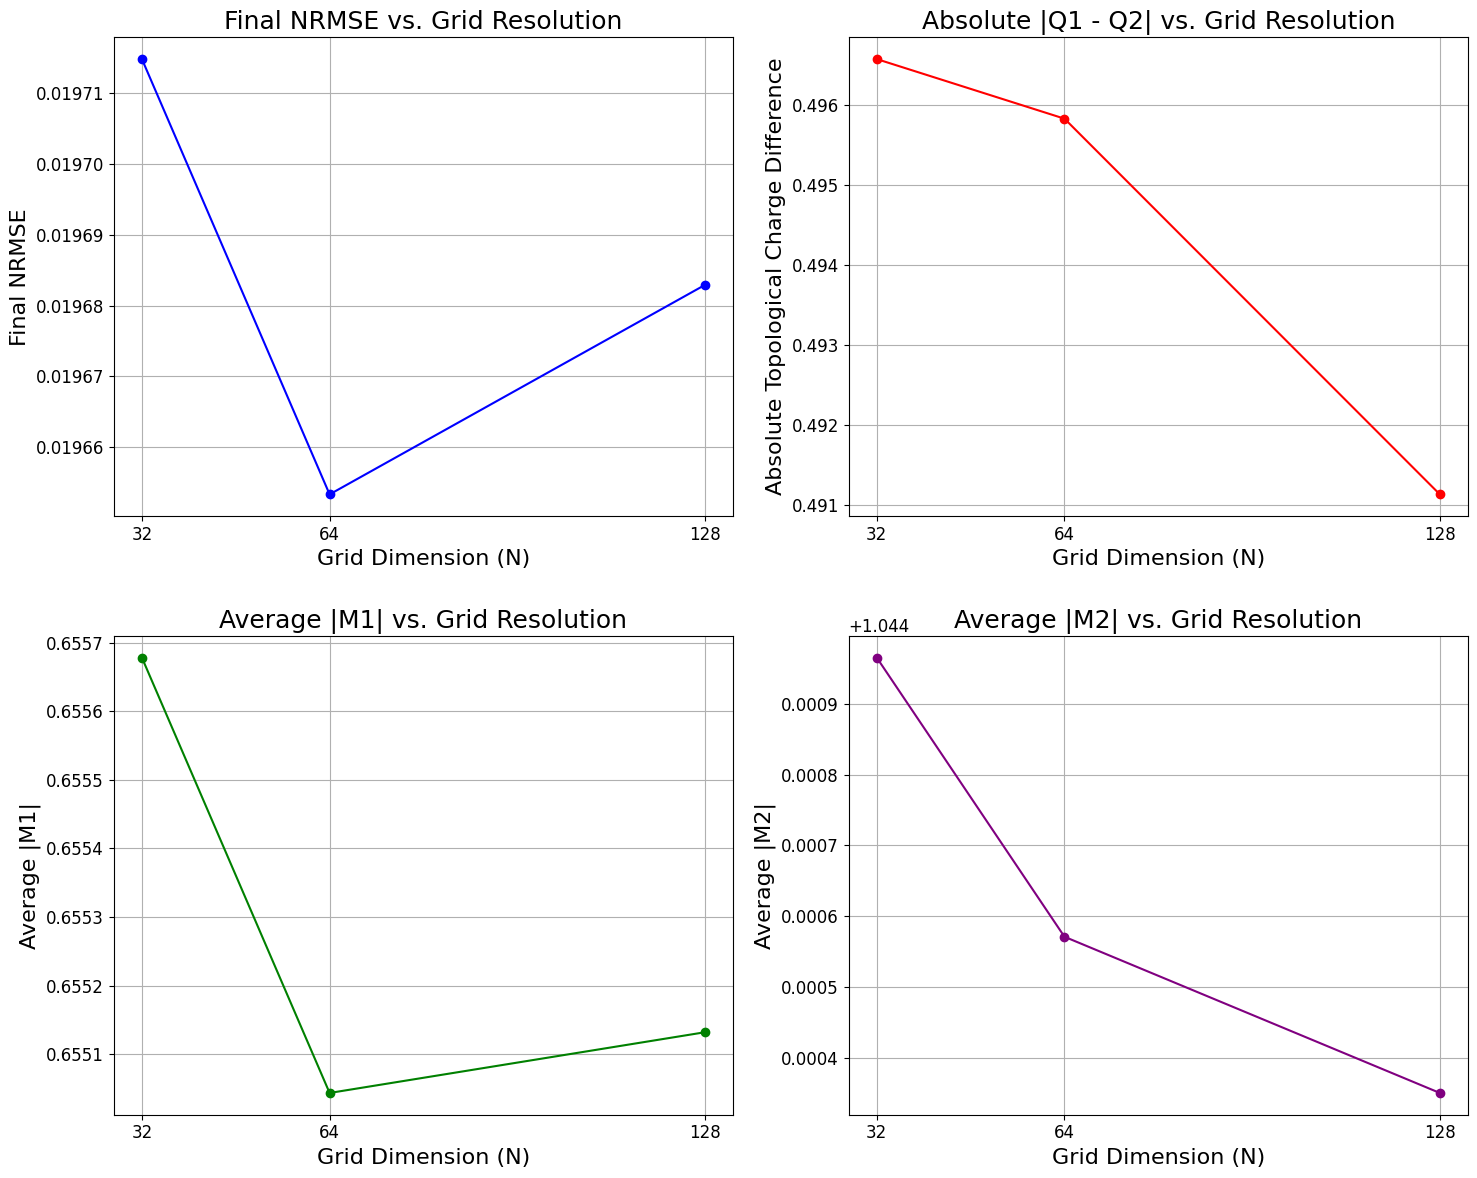

Plots generated for sensitivity analysis against grid resolution.


In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Extract grid dimensions for plotting (e.g., just nx since nx=ny)
grid_dimensions = [res[0] for res in grid_resolutions]

plt.figure(figsize=(15, 12))

# Plot 1: Final NRMSE vs. Grid Resolution
plt.subplot(2, 2, 1)
plt.plot(grid_dimensions, all_final_nrmse, marker='o', linestyle='-', color='blue')
plt.title('Final NRMSE vs. Grid Resolution')
plt.xlabel('Grid Dimension (N)')
plt.ylabel('Final NRMSE')
plt.xticks(grid_dimensions) # Ensure x-ticks align with data points
plt.grid(True)

# Plot 2: Absolute difference in topological charges vs. Grid Resolution
plt.subplot(2, 2, 2)
plt.plot(grid_dimensions, all_q_diff_abs, marker='o', linestyle='-', color='red')
plt.title('Absolute |Q1 - Q2| vs. Grid Resolution')
plt.xlabel('Grid Dimension (N)')
plt.ylabel('Absolute Topological Charge Difference')
plt.xticks(grid_dimensions)
plt.grid(True)

# Plot 3: Average magnitude of optimized M1 vs. Grid Resolution
plt.subplot(2, 2, 3)
plt.plot(grid_dimensions, all_m1_avg_magnitudes, marker='o', linestyle='-', color='green')
plt.title('Average |M1| vs. Grid Resolution')
plt.xlabel('Grid Dimension (N)')
plt.ylabel('Average |M1|')
plt.xticks(grid_dimensions)
plt.grid(True)

# Plot 4: Average magnitude of optimized M2 vs. Grid Resolution
plt.subplot(2, 2, 4)
plt.plot(grid_dimensions, all_m2_avg_magnitudes, marker='o', linestyle='-', color='purple')
plt.title('Average |M2| vs. Grid Resolution')
plt.xlabel('Grid Dimension (N)')
plt.ylabel('Average |M2|')
plt.xticks(grid_dimensions)
plt.grid(True)

plt.tight_layout()
plt.show()

print("Plots generated for sensitivity analysis against grid resolution.")

## Summary:

### Q&A
The optimization results show low sensitivity to grid resolution within the tested range. The final NRMSE, absolute difference in topological charges, and average magnetization magnitudes remain remarkably stable as the grid resolution increases from 32x32 to 128x128.

### Data Analysis Key Findings
*   **Final NRMSE Stability**: The Normalized Root Mean Square Error (NRMSE) remained consistently around 0.0197 across all tested grid resolutions (32x32, 64x64, 128x128).
*   **Topological Charge Difference Invariance**: The absolute difference in topological charges (|Q1 - Q2|) showed very little variation, hovering around 0.49 for all resolutions.
*   **Consistent Magnetization Magnitudes**: The average magnitudes of the optimized M1 (around 0.655) and M2 (around 1.044-1.045) were also notably stable across the different grid resolutions.
*   **Physical Parameter Scaling**: The `dx` and `dy` values correctly adapted to the grid resolution changes (e.g., from 2.00e-09 m for 32x32 to 5.00e-10 m for 128x128), ensuring a constant physical sample size of 64x64 nm.


